# Proyecto 1 — Métodos Estadísticos
Alina Carías (22539) y Ariela Mishaan (22052)

## 0. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              classification_report, confusion_matrix,
                              mean_squared_error, r2_score)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import gaussian_kde
import scipy.cluster.hierarchy as sch

## 1. Carga y limpieza de datos

In [2]:
DATA_DIR = Path('/Users/arielamishaancohen/Documentos/Datasets gigantes/Ecobici')
files = sorted(DATA_DIR.glob('*.csv'))

COLS = ['Genero_Usuario','Edad_Usuario','Bici',
        'Ciclo_Estacion_Retiro','Fecha_Retiro','Hora_Retiro',
        'Ciclo_EstacionArribo','Fecha_Arribo','Hora_Arribo']

dfs = []
for f in files:
    try:
        tmp = pd.read_csv(f, usecols=range(9), names=COLS, header=0,
                          on_bad_lines='skip', engine='python')
        tmp['_archivo'] = f.name
        dfs.append(tmp)
        print(f"OK  {f.name:45s} → {len(tmp):>8,} filas")
    except Exception as e:
        print(f'ERR {f.name}: {e}')

df = pd.concat(dfs, ignore_index=True)
print(f'Dataset combinado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

OK  2024-01.csv                                   → 1,467,594 filas
OK  2024-02.csv                                   → 1,557,176 filas
OK  2024-03.csv                                   → 1,829,763 filas
OK  2024-04.csv                                   → 1,961,633 filas
OK  2024-05.csv                                   → 1,513,369 filas
OK  2024-06.csv                                   → 1,893,520 filas
OK  2024-07.csv                                   → 1,065,474 filas
OK  2024-08.csv                                   → 1,513,016 filas
OK  2024-09.csv                                   → 1,852,179 filas
OK  2024-10.csv                                   → 2,054,609 filas
OK  2024-11.csv                                   → 1,942,474 filas
OK  2024-12.csv                                   → 1,680,650 filas
OK  2025-01.csv                                   → 1,809,775 filas
OK  2025-02.csv                                   → 1,745,620 filas
OK  2025-03.csv                                 

In [3]:
# ── fechas y variables derivadas ──────────────────────────────────────────
df['Fecha_Retiro'] = pd.to_datetime(df['Fecha_Retiro'], dayfirst=True, errors='coerce')
df['Fecha_Arribo'] = pd.to_datetime(df['Fecha_Arribo'], dayfirst=True, errors='coerce')

df['dt_retiro'] = pd.to_datetime(
    df['Fecha_Retiro'].dt.strftime('%Y-%m-%d') + ' ' + df['Hora_Retiro'].astype(str),
    errors='coerce')
df['dt_arribo'] = pd.to_datetime(
    df['Fecha_Arribo'].dt.strftime('%Y-%m-%d') + ' ' + df['Hora_Arribo'].astype(str),
    errors='coerce')

df['duracion_min']  = (df['dt_arribo'] - df['dt_retiro']).dt.total_seconds() / 60
df['anio']          = df['dt_retiro'].dt.year
df['mes']           = df['dt_retiro'].dt.month
df['dia_semana']    = df['dt_retiro'].dt.day_name()
df['hora_retiro']   = df['dt_retiro'].dt.hour
df['es_circular']   = (df['Ciclo_Estacion_Retiro'].astype(str) ==
                       df['Ciclo_EstacionArribo'].astype(str))
df['Genero_Usuario'] = df['Genero_Usuario'].str.strip().str.upper()

# filtro de viajes válidos
df_clean = df[(df['duracion_min'] > 0) & (df['duracion_min'] <= 180)].copy()
print(f'df_clean: {df_clean.shape[0]:,} filas')

df_clean: 43,574,938 filas


In [4]:
df_clean = df_clean.sample(n=1_000_000, random_state=42)

In [5]:
import requests
import pandas as pd

# URL de estaciones
url = "https://gbfs.mex.lyftbikes.com/gbfs/en/station_information.json"

# request
res = requests.get(url)
data = res.json()

# extraer estaciones
stations = data['data']['stations']

# dataframe
df_stations = pd.DataFrame(stations)

# ver columnas
print(df_stations.columns)
df_stations.head()

Index(['station_id', 'external_id', 'name', 'short_name', 'lat', 'lon',
       'rental_methods', 'capacity', 'electric_bike_surcharge_waiver',
       'is_charging', 'eightd_has_key_dispenser', 'has_kiosk'],
      dtype='object')


,station_id,external_id,name,short_name,lat,lon,rental_methods,capacity,electric_bike_surcharge_waiver,is_charging,eightd_has_key_dispenser,has_kiosk
0,1,e961269c-34c4-4b70-8e30-a51aa95a8429,CE-710 Molino del Rey - Glorieta de la Lealtad,710,19.416795,-99.192508,"[CREDITCARD, KEY]",39,False,False,False,True
1,5,3ea89109-d2f3-46eb-9c41-c43742050340,CE-407 Prolongación Xochicalco-General Emilia...,407,19.367266,-99.158656,"[CREDITCARD, KEY]",19,False,False,False,True
2,6,ba78b703-4e5a-44bd-ab2c-1eedc71e11c3,CE-428 Prolongación Uxmal-Av. Popocatépetl (E...,428,19.363404,-99.160395,"[CREDITCARD, KEY]",27,False,False,False,True
3,7,6563d263-2342-46e3-8983-461e68d2d615,CE-427 Avenida México-Coyoacán-Av. Popocatépet...,427,19.364906,-99.162987,"[CREDITCARD, KEY]",19,False,False,False,True
4,8,ec55e597-c8fc-4e86-bcfe-b0e81a494790,CE-443 Bruno Traven-Golondrinas,443,19.359583,-99.162085,"[CREDITCARD, KEY]",31,False,False,False,True


In [6]:
df_merged = df_clean.merge(
    df_stations[['station_id','lat','lon']],
    left_on='Ciclo_Estacion_Retiro',
    right_on='station_id',
    how='left'
)

df_clean = df_merged.merge(
    df_stations[['station_id','lat','lon']],
    left_on='Ciclo_EstacionArribo',
    right_on='station_id',
    how='left',
    suffixes=('_retiro', '_arribo')
)

In [7]:
df_clean.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,_archivo,...,mes,dia_semana,hora_retiro,es_circular,station_id_retiro,lat_retiro,lon_retiro,station_id_arribo,lat_arribo,lon_arribo
0,F,22.0,7011471,683,2024-08-27,13:20:35,700,2024-08-27,13:38:31,2024-08.csv,...,8.0,Tuesday,13.0,False,683,19.361792,-99.171471,700,19.414108,-99.191983
1,M,37.0,7049539,219,2025-04-07,09:56:11,477,2025-04-07,10:14:29,2025-04.csv,...,4.0,Monday,9.0,False,219,19.427862,-99.191405,477,19.453146,-99.166455
2,F,32.0,4467304,182,2024-02-25,13:28:41,632,2024-02-25,14:08:36,2024-02.csv,...,2.0,Sunday,13.0,False,182,19.399763,-99.177538,632,19.464964,-99.160455
3,M,29.0,5945217,331,2026-01-06,18:09:23,617,2026-01-06,18:28:09,2026-01.csv,...,1.0,Tuesday,18.0,False,331,19.431172,-99.185612,617,19.354411,-99.147795
4,F,25.0,6167589,389,2026-01-05,17:22:04,302,2026-01-05,17:37:22,2026-01.csv,...,1.0,Monday,17.0,False,389,19.385751,-99.186297,302,19.433850,-99.188275


## 2. Codificación de variables categóricas (dummies)

Antes de aplicar cualquier método necesitamos que todas las variables sean numéricas.
Las variables categóricas se transforman así:

- **Genero_Usuario** (M / F) → dummy binario (0 = F, 1 = M)
- **dia_semana** → 7 dummies con drop_first=True (evita multicolinealidad perfecta)
- **es_circular** (bool) → entero 0/1
- Las variables ya numéricas (`duracion_min`, `Edad_Usuario`, etc.) se mantienen igual.

> **Por qué usar get_dummies y no LabelEncoder para categorías nominales:**
> LabelEncoder asigna 1, 2, 3... lo que implica un orden artificial que no existe
> (lunes < martes no tiene sentido). get_dummies crea columnas independientes para
> cada categoría, sin imponer ningún orden.

In [8]:
# ── Dummies de género ────────────────────────────────────────────────────
genero_valido = df_clean['Genero_Usuario'].isin(['M','F'])
df_model = df_clean[genero_valido].copy()

df_model['genero_M'] = (df_model['Genero_Usuario'] == 'M').astype(int)

# ── Dummies de día de la semana (drop_first para evitar trampa de dummies) ─
df_model['weekend'] = df_model['dia_semana'].isin(['Saturday','Sunday']).astype(int)

#dia_dummies = pd.get_dummies(df_model['dia_semana'], prefix='dia', drop_first=True)
#df_model = pd.concat([df_model, dia_dummies], axis=1) --> ya no porque es solo una misma información, mejor se usa weekend

# ── Circulares a entero ───────────────────────────────────────────────────
df_model['es_circular'] = df_model['es_circular'].astype(int)

# ── Lista final de features para los modelos ──────────────────────────────
FEATURES = (['duracion_min', 'Edad_Usuario', 'hora_retiro', 'mes',
              'genero_M', 'es_circular', 'weekend', 'lat_retiro', 'lon_retiro'])

print('Features disponibles:')
for f in FEATURES:
    print(f'  {f}  ({df_model[f].dtype})')

print(f'\nShape df_model: {df_model.shape}')
print(f'Nulos en features: {df_model[FEATURES].isnull().sum().sum()}')

Features disponibles:
  duracion_min  (float64)
  Edad_Usuario  (float64)
  hora_retiro  (float64)
  mes  (float64)
  genero_M  (int64)
  es_circular  (int64)
  weekend  (int64)
  lat_retiro  (float64)
  lon_retiro  (float64)

Shape df_model: (967556, 26)
Nulos en features: 595485


In [9]:
df_model.head()

,Genero_Usuario,Edad_Usuario,Bici,Ciclo_Estacion_Retiro,Fecha_Retiro,Hora_Retiro,Ciclo_EstacionArribo,Fecha_Arribo,Hora_Arribo,_archivo,...,hora_retiro,es_circular,station_id_retiro,lat_retiro,lon_retiro,station_id_arribo,lat_arribo,lon_arribo,genero_M,weekend
0,F,22.0,7011471,683,2024-08-27,13:20:35,700,2024-08-27,13:38:31,2024-08.csv,...,13.0,0,683,19.361792,-99.171471,700,19.414108,-99.191983,0,0
1,M,37.0,7049539,219,2025-04-07,09:56:11,477,2025-04-07,10:14:29,2025-04.csv,...,9.0,0,219,19.427862,-99.191405,477,19.453146,-99.166455,1,0
2,F,32.0,4467304,182,2024-02-25,13:28:41,632,2024-02-25,14:08:36,2024-02.csv,...,13.0,0,182,19.399763,-99.177538,632,19.464964,-99.160455,0,1
3,M,29.0,5945217,331,2026-01-06,18:09:23,617,2026-01-06,18:28:09,2026-01.csv,...,18.0,0,331,19.431172,-99.185612,617,19.354411,-99.147795,1,0
4,F,25.0,6167589,389,2026-01-05,17:22:04,302,2026-01-05,17:37:22,2026-01.csv,...,17.0,0,389,19.385751,-99.186297,302,19.433850,-99.188275,0,0


## 3. Selección de variables

### 3.1 Correlación de Pearson
Detecta relaciones lineales entre variables numéricas continuas.
Variables con |r| > 0.7 son candidatas a redundancia (sólo conservamos una).

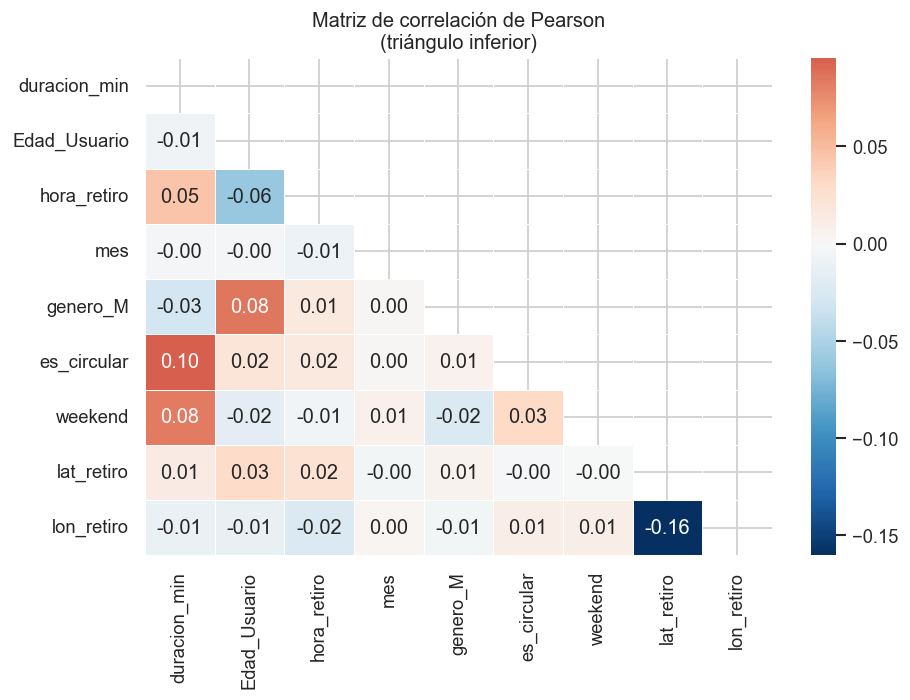

No hay pares con correlación |r| > 0.5 -> todas las variables aportan información independiente.


In [10]:
num_features = ['duracion_min','Edad_Usuario','hora_retiro','mes','genero_M','es_circular', 'weekend', 'lat_retiro', 'lon_retiro']

corr_matrix = df_model[num_features].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Matriz de correlación de Pearson\n(triángulo inferior)')
plt.tight_layout()
plt.show()

# resaltar pares con |r| > 0.5
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j])
             for i in range(len(corr_matrix))
             for j in range(i+1, len(corr_matrix))
             if abs(corr_matrix.iloc[i,j]) > 0.5]
if high_corr:
    print('Pares con |r| > 0.5:')
    for a,b,r in high_corr:
        print(f'  {a} vs {b}: r = {r:.3f}')
else:
    print('No hay pares con correlación |r| > 0.5 -> todas las variables aportan información independiente.')

### 3.2 Información Mutua
Mide dependencia estadística general (no sólo lineal). Más robusto que Pearson para relaciones no lineales.

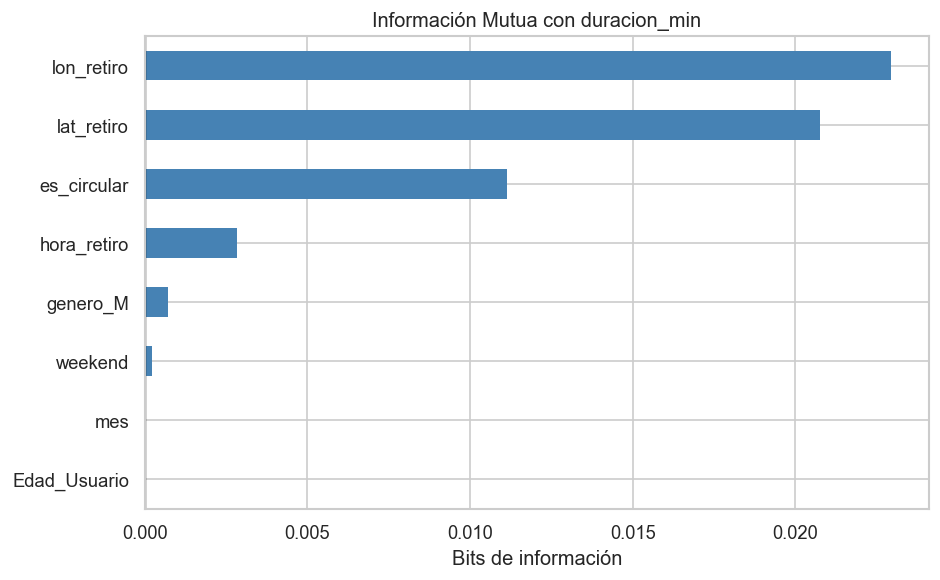

Variables con MI > 0.01 (relevantes para duración):
lon_retiro     0.022952
lat_retiro     0.020756
es_circular    0.011122


In [11]:
sample_mi = df_model[FEATURES].dropna().sample(50_000, random_state=42)
X_mi = sample_mi.drop(columns=['duracion_min'])
y_mi = sample_mi['duracion_min']

mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
mi_series.plot.barh(ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Información Mutua con duracion_min')
ax.set_xlabel('Bits de información')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

print('Variables con MI > 0.01 (relevantes para duración):')
print(mi_series[mi_series > 0.01].sort_values(ascending=False).to_string())

### 3.3 LASSO — selección automática con penalización
LASSO penaliza la norma L1 de los coeficientes; variables irrelevantes quedan en exactamente 0.

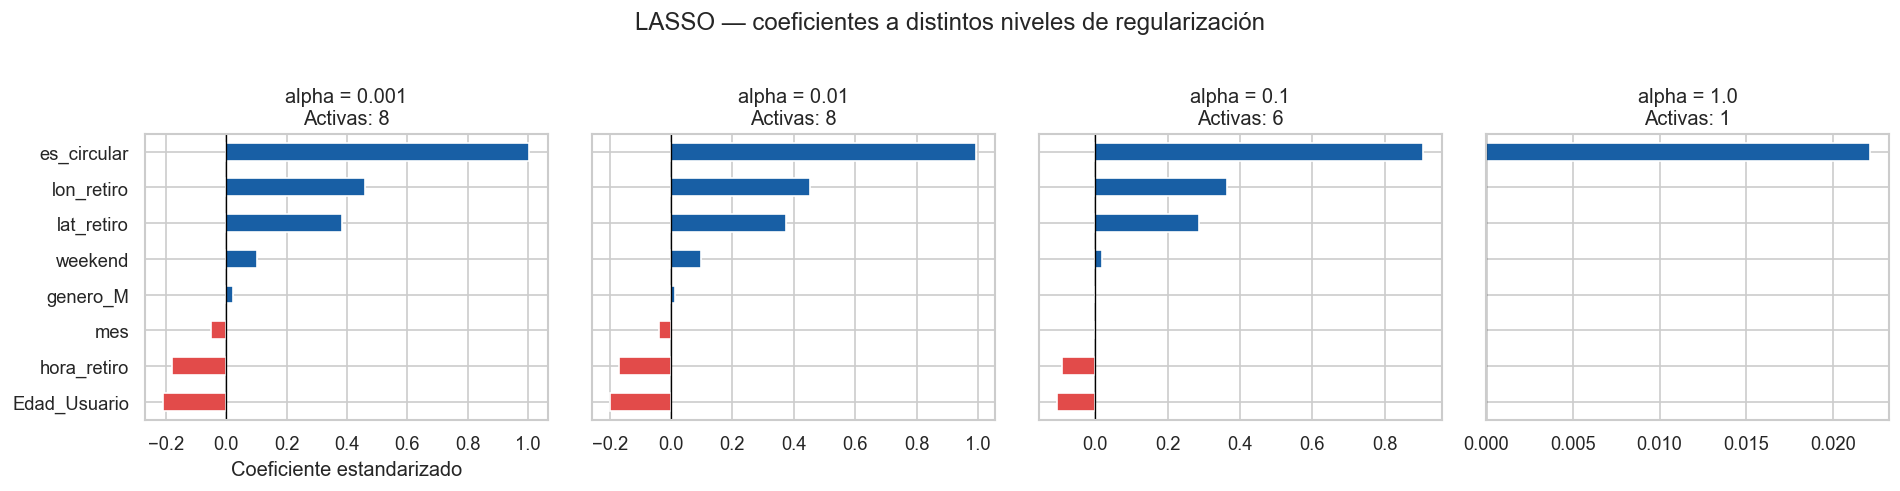

Variables seleccionadas por LASSO (alpha=0.01): ['Edad_Usuario', 'hora_retiro', 'mes', 'genero_M', 'es_circular', 'weekend', 'lat_retiro', 'lon_retiro']


In [12]:
sample_lasso = df_model[FEATURES].dropna().sample(100_000, random_state=42)
X_lasso = sample_lasso.drop(columns=['duracion_min'])
y_lasso = sample_lasso['duracion_min']

scaler_lasso = StandardScaler()
X_lasso_sc = scaler_lasso.fit_transform(X_lasso)

alphas = [0.001, 0.01, 0.1, 1.0]
fig, axes = plt.subplots(1, len(alphas), figsize=(16, 4), sharey=True)

for ax, alpha in zip(axes, alphas):
    lasso = Lasso(alpha=alpha, max_iter=5000)
    lasso.fit(X_lasso_sc, y_lasso)
    coefs = pd.Series(lasso.coef_, index=X_lasso.columns)
    coefs.sort_values().plot.barh(ax=ax, color=['#E24B4A' if v < 0 else '#185FA5' for v in coefs.sort_values()])
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'alpha = {alpha}\nActivas: {(coefs != 0).sum()}')

axes[0].set_xlabel('Coeficiente estandarizado')
plt.suptitle('LASSO — coeficientes a distintos niveles de regularización', y=1.02)
plt.tight_layout()
plt.show()

# Variables seleccionadas con alpha=0.01
lasso_final = Lasso(alpha=0.01, max_iter=5000)
lasso_final.fit(X_lasso_sc, y_lasso)
vars_seleccionadas = X_lasso.columns[(lasso_final.coef_ != 0)].tolist()
print(f'Variables seleccionadas por LASSO (alpha=0.01): {vars_seleccionadas}')

## 4. Preparación del conjunto de trabajo para los métodos

Usamos una muestra de 100 000 observaciones para que todos los métodos corran en tiempo razonable.
Se escalan TODAS las features (media 0, std 1) — requisito de PCA, K-Means, SVM, KDE, etc.

In [13]:
VARS_METODOS = ['duracion_min','Edad_Usuario','hora_retiro','mes','genero_M','es_circular', 'lat_retiro', 'lon_retiro']

df_work = df_model[VARS_METODOS].dropna().sample(100_000, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_work)
X_df     = pd.DataFrame(X_scaled, columns=VARS_METODOS)

print(f'Shape de trabajo: {X_df.shape}')
print(f'Media por columna (debe ser ~0): {X_df.mean().round(6).to_dict()}')
print(f'Std  por columna (debe ser ~1): {X_df.std().round(6).to_dict()}')

Shape de trabajo: (100000, 8)
Media por columna (debe ser ~0): {'duracion_min': 0.0, 'Edad_Usuario': 0.0, 'hora_retiro': -0.0, 'mes': -0.0, 'genero_M': 0.0, 'es_circular': 0.0, 'lat_retiro': 0.0, 'lon_retiro': 0.0}
Std  por columna (debe ser ~1): {'duracion_min': 1.000005, 'Edad_Usuario': 1.000005, 'hora_retiro': 1.000005, 'mes': 1.000005, 'genero_M': 1.000005, 'es_circular': 1.000005, 'lat_retiro': 1.000005, 'lon_retiro': 1.000005}


## 5. PCA — Análisis de Componentes Principales

### ¿Qué hace PCA?
PCA busca las direcciones de máxima varianza en el espacio de features.
Cada componente principal (CP) es una combinación lineal de las variables originales,
y los CPs son ortogonales entre sí (no correlacionados).

### ¿Cuándo es útil?
- Reducir dimensionalidad manteniendo la mayor parte de la varianza.
- Visualizar datos de alta dimensión en 2D/3D.
- Eliminar multicolinealidad antes de regresión.

### Requisitos
- Variables numéricas **estandarizadas** (media 0, std 1). ✔ Ya hecho arriba.
- No asume ninguna distribución, pero funciona mejor cuando las relaciones son lineales.

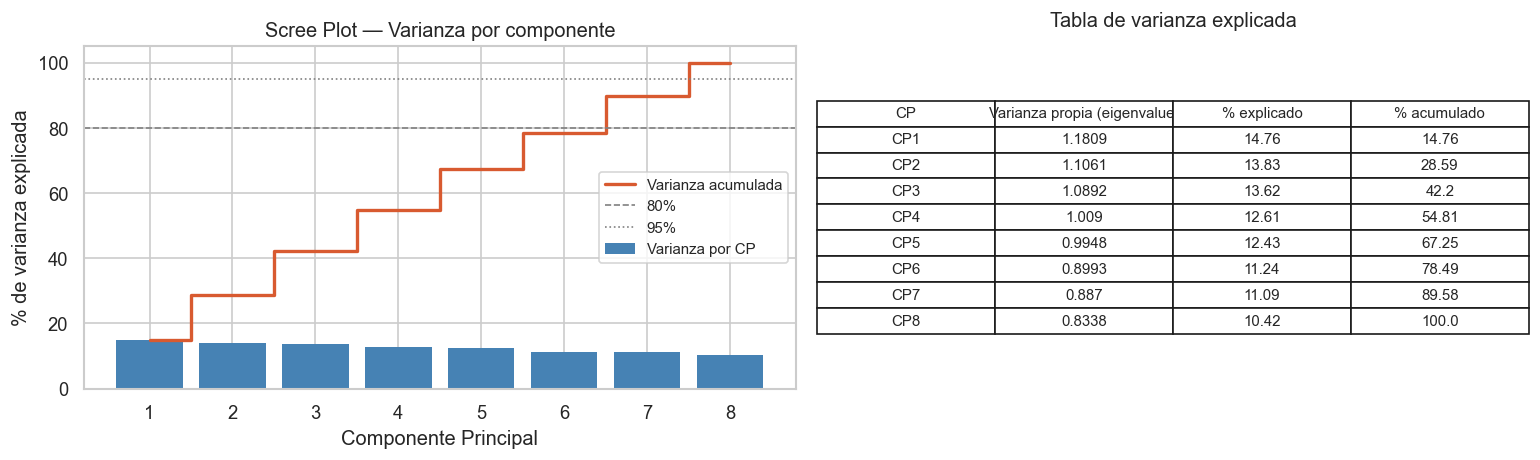

CPs para explicar >= 80% de varianza: 7
CPs para explicar >= 95% de varianza: 8


In [14]:
pca_full = PCA()
pca_full.fit(X_scaled)

ev_ratio  = pca_full.explained_variance_ratio_
ev_cumsum = np.cumsum(ev_ratio)
n_comp    = len(ev_ratio)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Scree plot ────────────────────────────────────────────────────────────
axes[0].bar(range(1, n_comp+1), ev_ratio * 100, color='steelblue', edgecolor='none', label='Varianza por CP')
axes[0].step(range(1, n_comp+1), ev_cumsum * 100, where='mid', color='#D85A30', linewidth=2, label='Varianza acumulada')
axes[0].axhline(80, color='gray', linestyle='--', lw=1, label='80%')
axes[0].axhline(95, color='gray', linestyle=':', lw=1, label='95%')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% de varianza explicada')
axes[0].set_title('Scree Plot — Varianza por componente')
axes[0].legend(fontsize=9)
axes[0].set_xticks(range(1, n_comp+1))

# ── Tabla numérica ────────────────────────────────────────────────────────
tabla = pd.DataFrame({
    'CP': [f'CP{i+1}' for i in range(n_comp)],
    'Varianza propia (eigenvalue)': pca_full.explained_variance_.round(4),
    '% explicado':     (ev_ratio * 100).round(2),
    '% acumulado':     (ev_cumsum * 100).round(2)
})
axes[1].axis('off')
tbl = axes[1].table(cellText=tabla.values, colLabels=tabla.columns,
                    loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.4)
axes[1].set_title('Tabla de varianza explicada', pad=12)

plt.tight_layout()
plt.show()

# ── Regla del codo: cuántos CPs explican >= 80% ───────────────────────────
n_80 = np.argmax(ev_cumsum >= 0.80) + 1
n_95 = np.argmax(ev_cumsum >= 0.95) + 1
print(f'CPs para explicar >= 80% de varianza: {n_80}')
print(f'CPs para explicar >= 95% de varianza: {n_95}')

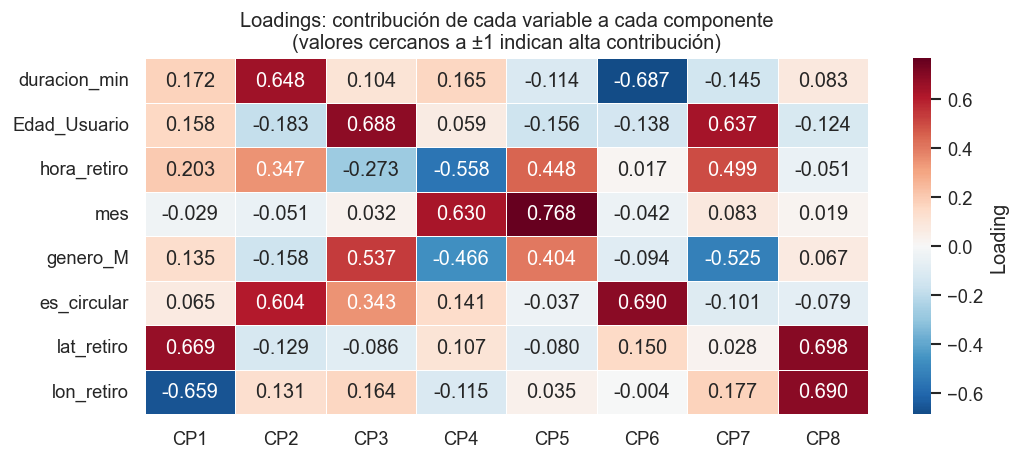


Interpretación de los loadings:
  - Un loading positivo alto (+) en una variable significa que los viajes con valores
    altos en esa variable tienen coordenadas POSITIVAS en ese eje.
  - Un loading negativo alto (-) significa lo contrario.
  - Valores cercanos a 0 indican que la variable no contribuye a ese eje.


Loadings de los primeros 2 CPs:
                   CP1       CP2
duracion_min  0.171821  0.648008
Edad_Usuario  0.158128 -0.183124
hora_retiro   0.203006  0.346877
mes          -0.028823 -0.051168
genero_M      0.134516 -0.157878
es_circular   0.065424  0.604051
lat_retiro    0.668876 -0.128898
lon_retiro   -0.658530  0.131114


In [15]:
# ── Loadings: contribución de cada variable a cada CP ────────────────────
loadings = pd.DataFrame(pca_full.components_.T,
                        index=VARS_METODOS,
                        columns=[f'CP{i+1}' for i in range(n_comp)])

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Loading'})
ax.set_title('Loadings: contribución de cada variable a cada componente\n'
             '(valores cercanos a ±1 indican alta contribución)')
plt.tight_layout()
plt.show()

print("""
Interpretación de los loadings:
  - Un loading positivo alto (+) en una variable significa que los viajes con valores
    altos en esa variable tienen coordenadas POSITIVAS en ese eje.
  - Un loading negativo alto (-) significa lo contrario.
  - Valores cercanos a 0 indican que la variable no contribuye a ese eje.
"""
)
print('\nLoadings de los primeros 2 CPs:')
print(loadings[['CP1','CP2']].to_string())

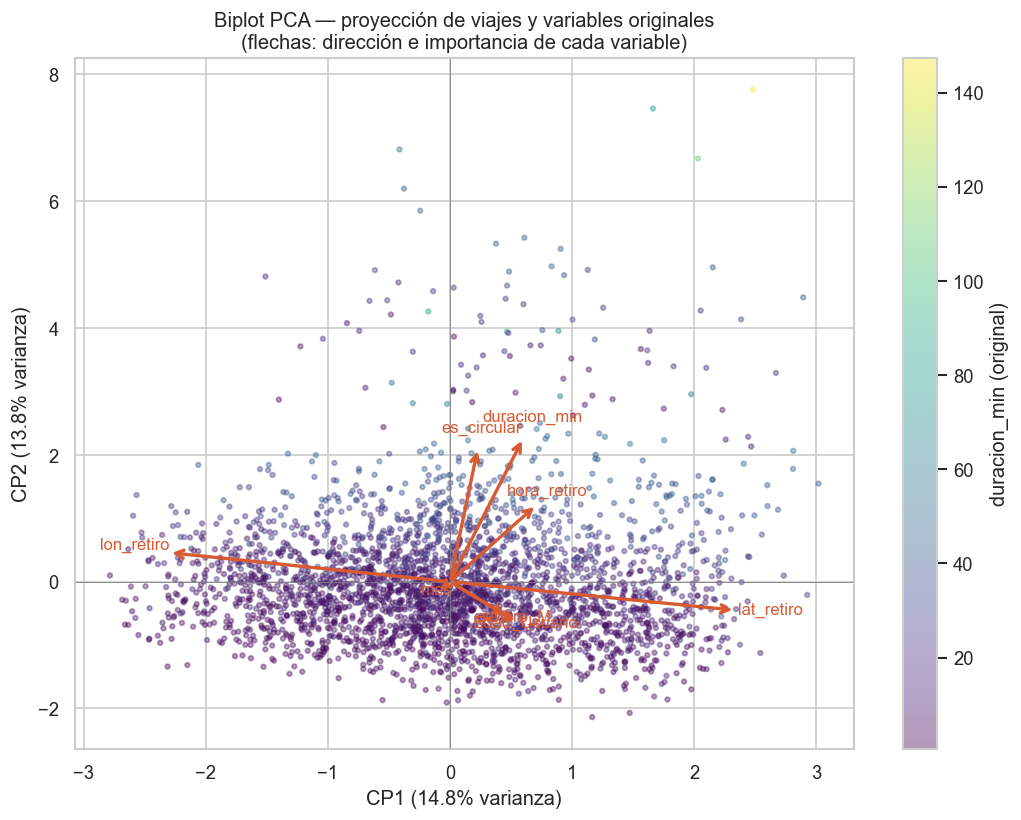


Varianza explicada:
  CP1: 14.76%
  CP2: 13.83%
  Total (2 CPs): 28.59%

Interpretación del biplot:
  - Flechas en la misma dirección -> variables correlacionadas positivamente en este espacio.
  - Flechas opuestas -> correlación negativa.
  - Flechas perpendiculares -> variables no relacionadas.
  - El color de los puntos muestra cómo se distribuye la duración del viaje a lo largo de los ejes.



In [16]:
# ── Biplot: proyección de viajes + flechas de variables originales ─────────
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

# muestra pequeña para el scatter
idx_sample = np.random.choice(len(X_pca2), 3000, replace=False)
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(X_pca2[idx_sample, 0], X_pca2[idx_sample, 1],
                     c=df_work['duracion_min'].values[idx_sample],
                     cmap='viridis', alpha=0.4, s=8, rasterized=True)
plt.colorbar(scatter, ax=ax, label='duracion_min (original)')

# flechas de loadings escaladas
scale = 3.5
for i, var in enumerate(VARS_METODOS):
    ax.annotate('', xy=(pca2.components_[0, i]*scale, pca2.components_[1, i]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#D85A30', lw=2))
    ax.text(pca2.components_[0, i]*scale*1.12, pca2.components_[1, i]*scale*1.12,
            var, fontsize=10, color='#D85A30', ha='center')

ax.set_xlabel(f'CP1 ({pca2.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'CP2 ({pca2.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Biplot PCA — proyección de viajes y variables originales\n'
             '(flechas: dirección e importancia de cada variable)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
plt.tight_layout()
plt.show()

print(f"""
Varianza explicada:
  CP1: {pca2.explained_variance_ratio_[0]*100:.2f}%
  CP2: {pca2.explained_variance_ratio_[1]*100:.2f}%
  Total (2 CPs): {pca2.explained_variance_ratio_.sum()*100:.2f}%
\nInterpretación del biplot:
  - Flechas en la misma dirección -> variables correlacionadas positivamente en este espacio.
  - Flechas opuestas -> correlación negativa.
  - Flechas perpendiculares -> variables no relacionadas.
  - El color de los puntos muestra cómo se distribuye la duración del viaje a lo largo de los ejes.
"""
)

## 6. K-Means Clustering

### ¿Qué hace K-Means?
Agrupa las observaciones en K grupos minimizando la inercia (suma de distancias cuadradas
de cada punto a su centroide). Es un algoritmo iterativo de asignación-actualización.

### Supuestos y limitaciones
- Asume clusters **esféricos** (isótropos) y de tamaño similar.
- Sensible a outliers y a la escala de las variables (por eso estandarizamos).
- K debe definirse a priori — usamos el método del codo + silhouette para elegirlo.

### Métricas de evaluación
| Métrica | Qué mide | Mejor valor |
|---|---|---|
| Inercia (WCSS) | Compacidad interna | Menor |
| Silhouette score | Separación entre clusters | Cercano a +1 |
| Davies-Bouldin | Ratio compacidad/separación | Menor |
| Calinski-Harabasz | Varianza entre/dentro | Mayor |

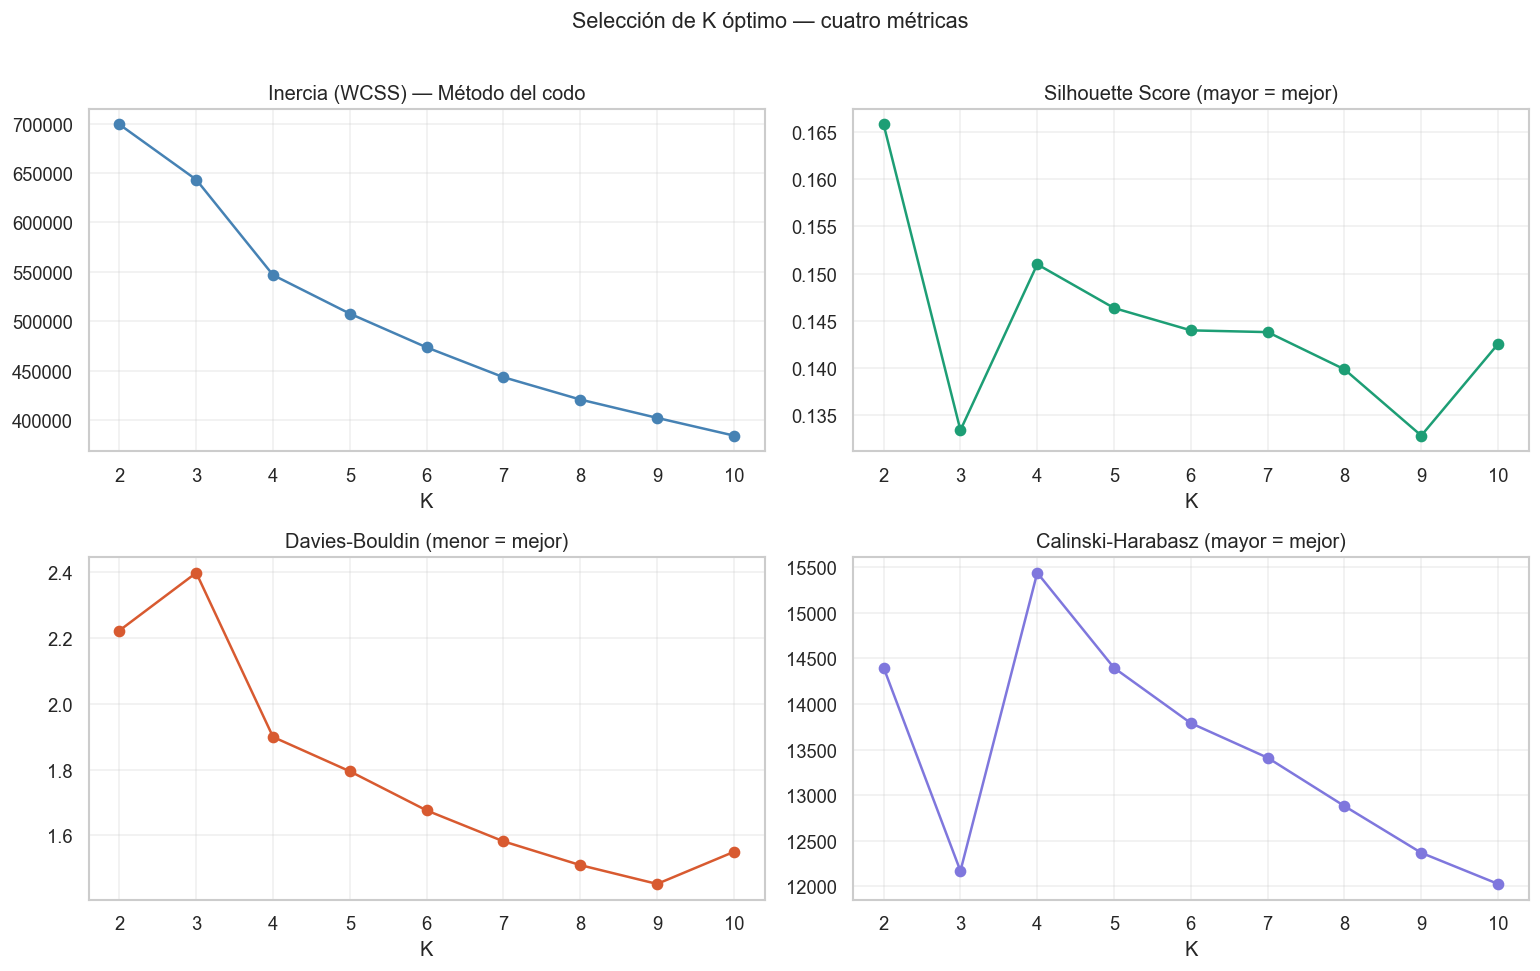

 K       Inercia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 699308.211538      0.1658          2.2231            14398.5
 3 643408.724303      0.1334          2.3986            12168.5
 4 546757.895118      0.1510          1.8995            15438.4
 5 507660.460440      0.1463          1.7951            14395.7
 6 473507.343332      0.1440          1.6761            13789.6
 7 443296.482114      0.1438          1.5822            13410.1
 8 420678.125885      0.1399          1.5099            12880.3
 9 402109.810255      0.1329          1.4526            12367.7
10 384157.919228      0.1425          1.5502            12026.3


In [17]:
# ── Método del codo + Silhouette para elegir K ────────────────────────────
K_range  = range(2, 11)
inercias = []
silhouettes = []
db_scores   = []
ch_scores   = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))
    db_scores.append(davies_bouldin_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0,0].plot(K_range, inercias, 'o-', color='steelblue')
axes[0,0].set_title('Inercia (WCSS) — Método del codo'); axes[0,0].set_xlabel('K')

axes[0,1].plot(K_range, silhouettes, 'o-', color='#1D9E75')
axes[0,1].set_title('Silhouette Score (mayor = mejor)'); axes[0,1].set_xlabel('K')

axes[1,0].plot(K_range, db_scores, 'o-', color='#D85A30')
axes[1,0].set_title('Davies-Bouldin (menor = mejor)'); axes[1,0].set_xlabel('K')

axes[1,1].plot(K_range, ch_scores, 'o-', color='#7F77DD')
axes[1,1].set_title('Calinski-Harabasz (mayor = mejor)'); axes[1,1].set_xlabel('K')

for ax in axes.flatten():
    ax.set_xticks(list(K_range))
    ax.grid(True, alpha=0.3)

plt.suptitle('Selección de K óptimo — cuatro métricas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# tabla resumen
df_metricas = pd.DataFrame({
    'K': list(K_range), 'Inercia': inercias,
    'Silhouette': np.round(silhouettes, 4),
    'Davies-Bouldin': np.round(db_scores, 4),
    'Calinski-Harabasz': np.round(ch_scores, 1)
})
print(df_metricas.to_string(index=False))

In [18]:
# ── Ajuste final con K óptimo ─────────────────────────────────────────────
# Ajusta este valor según lo que indiquen las métricas arriba
K_OPTIMO = 4

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_work = df_work.copy()
df_work['cluster_kmeans'] = km_final.fit_predict(X_scaled)

# ── Perfil de cada cluster ────────────────────────────────────────────────
perfil = df_work.groupby('cluster_kmeans')[VARS_METODOS].mean()
print('Perfil de centroides (valores originales, sin escalar):')
print(perfil.round(2).to_string())

Perfil de centroides (valores originales, sin escalar):
                duracion_min  Edad_Usuario  hora_retiro   mes  genero_M  es_circular  lat_retiro  lon_retiro
cluster_kmeans                                                                                              
0                      14.95         32.71        13.75  6.08      0.00          0.0       19.41      -99.17
1                      14.48         34.35        13.85  9.60      1.00          0.0       19.41      -99.17
2                      14.45         34.36        13.99  3.17      1.00          0.0       19.41      -99.17
3                      20.75         35.43        14.43  6.15      0.73          1.0       19.41      -99.17


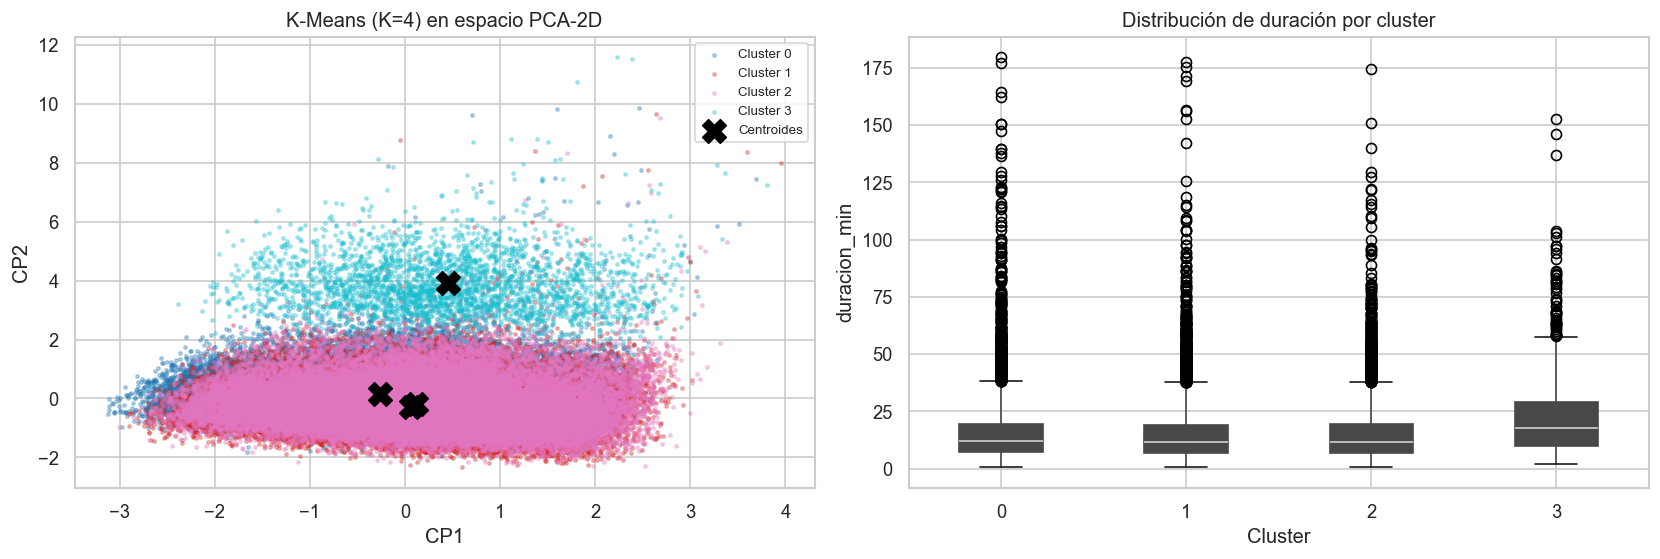


Silhouette final (K=4): 0.1510
Davies-Bouldin  (K=4): 1.8995



In [19]:
# ── Visualización en espacio PCA-2D ───────────────────────────────────────
X_pca2_km = pca2.transform(X_scaled)   # reutiliza el PCA de 2 componentes de antes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_k  = plt.cm.tab10(np.linspace(0, 1, K_OPTIMO))

for k in range(K_OPTIMO):
    mask = df_work['cluster_kmeans'] == k
    axes[0].scatter(X_pca2_km[mask.values, 0], X_pca2_km[mask.values, 1],
                    s=4, alpha=0.3, color=colors_k[k], label=f'Cluster {k}', rasterized=True)

centroides_2d = pca2.transform(km_final.cluster_centers_)
axes[0].scatter(centroides_2d[:, 0], centroides_2d[:, 1],
                s=200, marker='X', color='black', zorder=5, label='Centroides')
axes[0].set_xlabel(f'CP1'); axes[0].set_ylabel(f'CP2')
axes[0].set_title(f'K-Means (K={K_OPTIMO}) en espacio PCA-2D')
axes[0].legend(fontsize=8)

# boxplots de duración por cluster
df_work.boxplot(column='duracion_min', by='cluster_kmeans', ax=axes[1],
                patch_artist=True)
axes[1].set_title('Distribución de duración por cluster')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('duracion_min')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(f"""
Silhouette final (K={K_OPTIMO}): {silhouette_score(X_scaled, df_work['cluster_kmeans'], sample_size=10000, random_state=42):.4f}
Davies-Bouldin  (K={K_OPTIMO}): {davies_bouldin_score(X_scaled, df_work['cluster_kmeans']):.4f}
"""
)

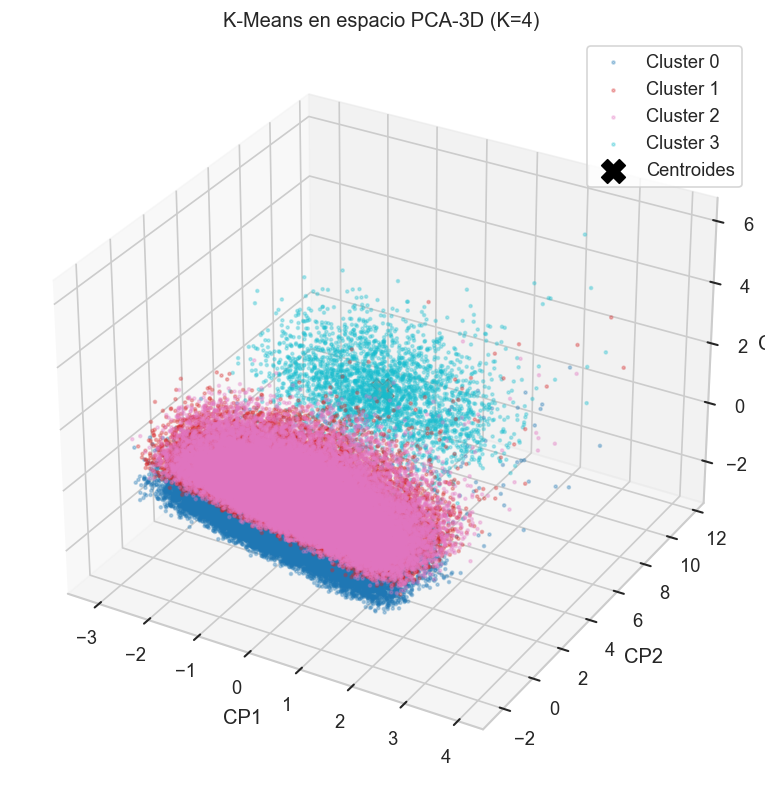

In [20]:
# ── Visualización en espacio PCA-3D ───────────────────────────────────────

pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

colors_k = plt.cm.tab10(np.linspace(0, 1, K_OPTIMO))

for k in range(K_OPTIMO):
    mask = df_work['cluster_kmeans'] == k
    
    ax.scatter(
        X_pca3[mask.values, 0],
        X_pca3[mask.values, 1],
        X_pca3[mask.values, 2],
        s=3,
        alpha=0.3,
        color=colors_k[k],
        label=f'Cluster {k}'
    )

# centroides
centroides_3d = pca3.transform(km_final.cluster_centers_)

ax.scatter(
    centroides_3d[:, 0],
    centroides_3d[:, 1],
    centroides_3d[:, 2],
    s=200,
    marker='X',
    color='black',
    label='Centroides'
)

ax.set_xlabel('CP1')
ax.set_ylabel('CP2')
ax.set_zlabel('CP3')
ax.set_title(f'K-Means en espacio PCA-3D (K={K_OPTIMO})')

ax.legend()
plt.show()

## 7. Clustering Jerárquico

### ¿Qué hace?
Construye un árbol (dendrograma) de fusiones entre observaciones.
No requiere especificar K de antemano: se corta el árbol a la altura deseada.

### Tipos de linkage
| Linkage | Criterio de fusión | Clusters resultantes |
|---|---|---|
| **Ward** | Minimiza varianza intra-cluster | Compactos, similares en tamaño |
| Complete | Distancia máxima entre puntos | Más compactos que single |
| Average | Distancia promedio | Intermedio |
| Single | Distancia mínima (vecino más cercano) | Encadenamiento, irregular |

Usamos **Ward** porque produce clusters similares a K-Means y es el más interpretable.

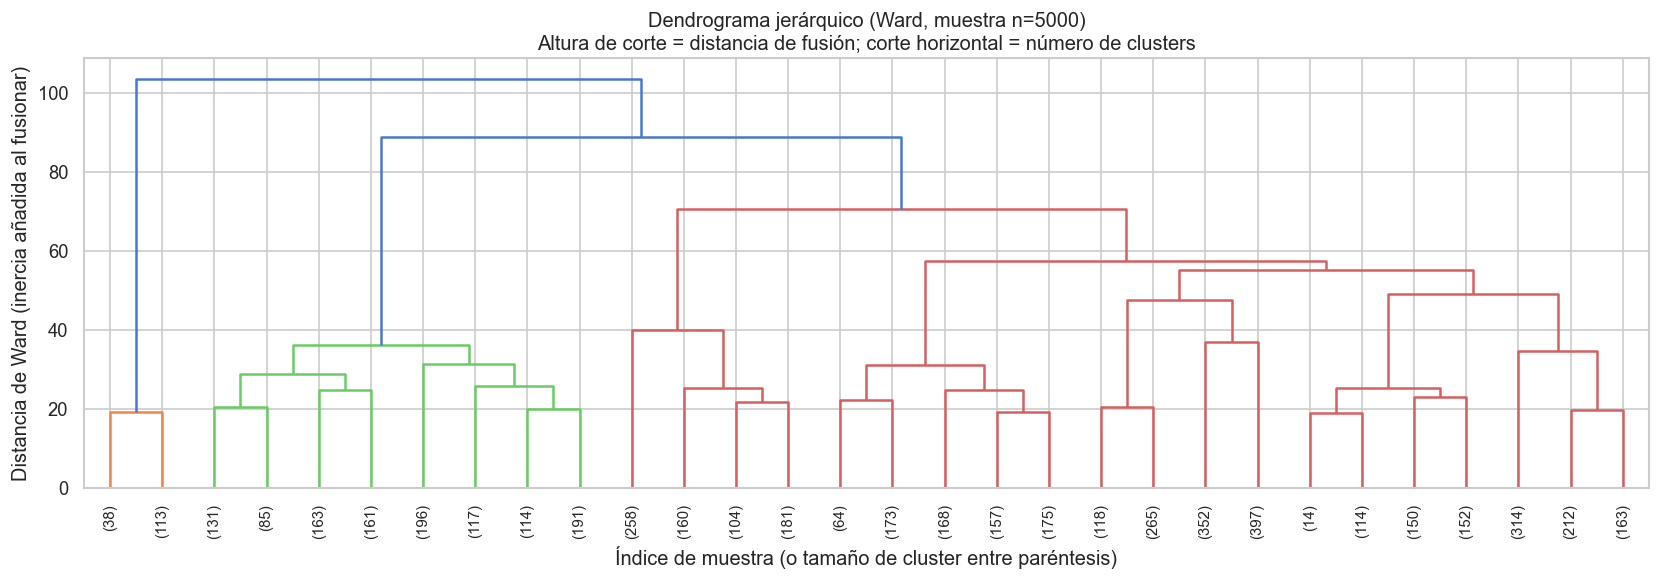


Interpretación del dendrograma:
  - Eje Y: distancia a la que dos clusters se fusionan. Saltos grandes indican
    que los clusters eran muy distintos antes de fusionarse -> buen punto de corte.
  - El número de clusters se lee contando cuántas líneas verticales cruza
    una línea horizontal trazada a cierta altura.
  - La altura de corte recomendada está marcada con color_threshold arriba.



In [21]:
# Muestra pequeña para el dendrograma (5 000 puntos máximo)
N_DENDRO = 5000
idx_h    = np.random.choice(len(X_scaled), N_DENDRO, replace=False)
X_h      = X_scaled[idx_h]

Z = linkage(X_h, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7 * max(Z[:,2]))

ax.set_title(f'Dendrograma jerárquico (Ward, muestra n={N_DENDRO})\n'
             'Altura de corte = distancia de fusión; corte horizontal = número de clusters')
ax.set_xlabel('Índice de muestra (o tamaño de cluster entre paréntesis)')
ax.set_ylabel('Distancia de Ward (inercia añadida al fusionar)')
plt.tight_layout()
plt.show()

print("""
Interpretación del dendrograma:
  - Eje Y: distancia a la que dos clusters se fusionan. Saltos grandes indican
    que los clusters eran muy distintos antes de fusionarse -> buen punto de corte.
  - El número de clusters se lee contando cuántas líneas verticales cruza
    una línea horizontal trazada a cierta altura.
  - La altura de corte recomendada está marcada con color_threshold arriba.
""")

In [22]:
# ── Elegir K comparando con las métricas del dendrograma ─────────────────
# ── Submuestreo para clustering jerárquico (evitar crash) ────────────────

N_HIER = 20000  # tamaño manejable
np.random.seed(42)

idx = np.random.choice(len(X_scaled), size=N_HIER, replace=False)
X_small = X_scaled[idx]

# ── Dendrograma / linkage sobre muestra ──────────────────────────────────
from scipy.cluster.hierarchy import linkage

Z = linkage(X_small, method='ward')

# analizar últimas fusiones
ultimas_fusiones = pd.DataFrame(
    Z[-15:], columns=['cluster_1','cluster_2','distancia','n_puntos']
)
ultimas_fusiones['salto'] = ultimas_fusiones['distancia'].diff().fillna(0)

print('Últimas 15 fusiones (busca el salto más grande en distancia):')
print(ultimas_fusiones[['distancia','salto']].round(3).to_string())

# ── Asignación de clusters jerárquicos SOLO en la muestra ────────────────
from sklearn.cluster import AgglomerativeClustering

K_HIER = K_OPTIMO  # mismo K que K-Means

hier = AgglomerativeClustering(n_clusters=K_HIER, linkage='ward')
labels_small = hier.fit_predict(X_small)

# guardar resultados en dataframe reducido
df_small = df_work.iloc[idx].copy()
df_small['cluster_hier'] = labels_small

print(f'\nClusters jerárquicos (K={K_HIER}) en muestra:')
print(df_small['cluster_hier'].value_counts().sort_index())

Últimas 15 fusiones (busca el salto más grande en distancia):
    distancia   salto
0      58.667   0.000
1      59.344   0.677
2      61.188   1.844
3      64.402   3.214
4      68.886   4.484
5      69.668   0.782
6      71.406   1.739
7      72.027   0.621
8      84.761  12.734
9      99.123  14.362
10    103.168   4.045
11    133.116  29.948
12    138.631   5.514
13    168.945  30.314
14    207.511  38.566

Clusters jerárquicos (K=4) en muestra:
cluster_hier
0    5458
1    9555
2    4383
3     604
Name: count, dtype: int64


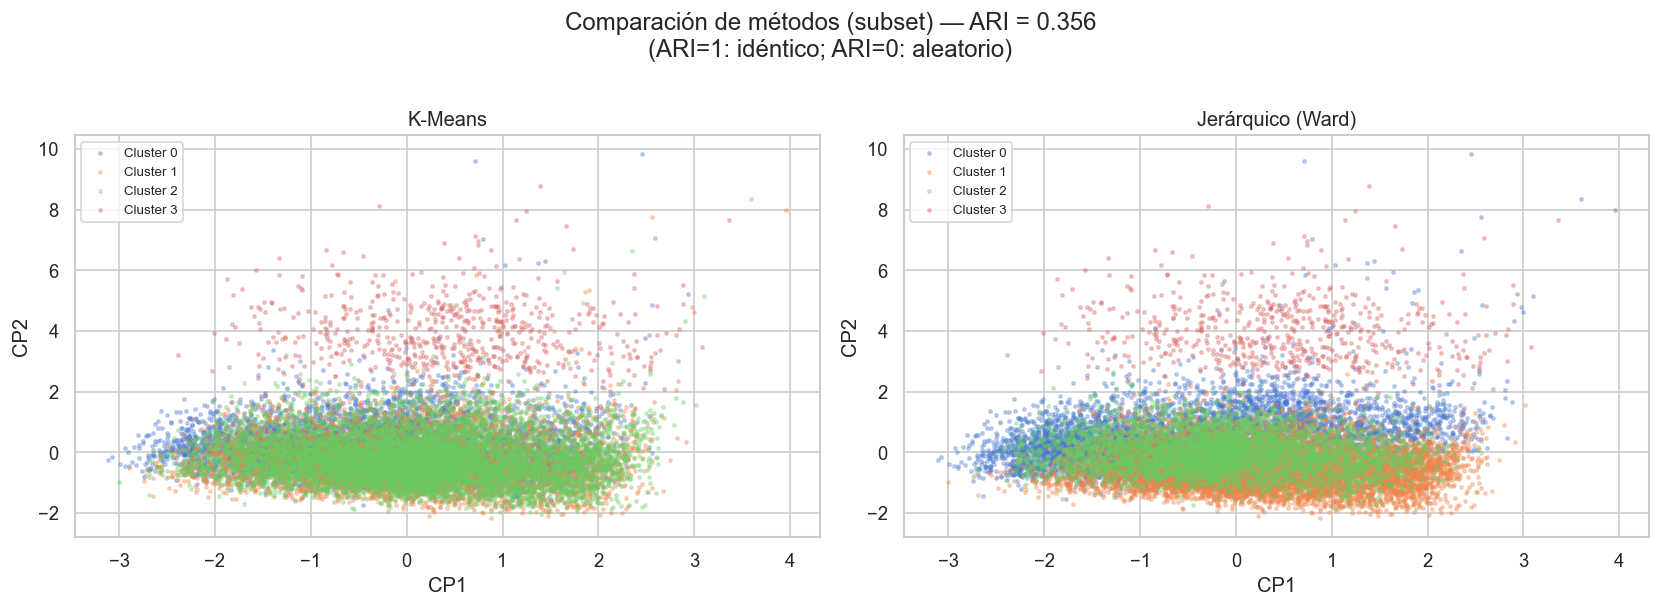

Silhouette K-Means:     0.1507
Silhouette Jerárquico:  0.1342
ARI entre métodos:      0.3556


In [25]:
# ── Comparación K-Means vs Jerárquico (sobre misma muestra) ───────────────
from sklearn.metrics import adjusted_rand_score, silhouette_score

# usar SOLO df_small (donde sí existe cluster_hier)
df_compare = df_small.copy()

# obtener labels de KMeans para ese mismo subset
labels_km_small = df_compare['cluster_kmeans'].values
labels_hier = df_compare['cluster_hier'].values

# ARI
ari = adjusted_rand_score(labels_km_small, labels_hier)

# PCA (solo para subset)
X_pca2_small = pca2.transform(X_scaled[idx])

# ── PLOTS ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in zip(
    axes,
    [labels_km_small, labels_hier],
    ['K-Means', 'Jerárquico (Ward)']
):
    for k in range(K_HIER):
        mask = labels == k
        ax.scatter(
            X_pca2_small[mask, 0],
            X_pca2_small[mask, 1],
            s=4,
            alpha=0.3,
            label=f'Cluster {k}',
            rasterized=True
        )
    ax.set_xlabel('CP1')
    ax.set_ylabel('CP2')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(
    f'Comparación de métodos (subset) — ARI = {ari:.3f}\n'
    '(ARI=1: idéntico; ARI=0: aleatorio)',
    y=1.01
)

plt.tight_layout()
plt.show()

# ── Silhouette (también en subset) ───────────────────────────────────────
sil_km = silhouette_score(X_small, labels_km_small, sample_size=5000, random_state=42)
sil_hier = silhouette_score(X_small, labels_hier, sample_size=5000, random_state=42)

print(f'Silhouette K-Means:     {sil_km:.4f}')
print(f'Silhouette Jerárquico:  {sil_hier:.4f}')
print(f'ARI entre métodos:      {ari:.4f}')

## 8. Modelos de Mezcla Gaussiana (GMM) + Algoritmo EM

### ¿Qué hace GMM?
Asume que los datos provienen de una mezcla de K distribuciones gaussianas.
Cada observación tiene una **probabilidad de pertenecer a cada componente**
(asignación blanda), a diferencia de K-Means que hace asignación dura.

### Algoritmo EM
El entrenamiento usa **Expectation-Maximization**:
- **Paso E**: calcula la probabilidad posterior de cada punto para cada gaussiana.
- **Paso M**: actualiza los parámetros (media, covarianza, peso) de cada gaussiana
  para maximizar la verosimilitud esperada.

### Criterios de selección del número de componentes
- **BIC** (Bayesian Information Criterion): penaliza complejidad. **Menor = mejor.**
- **AIC** (Akaike Information Criterion): penaliza menos que BIC. **Menor = mejor.**

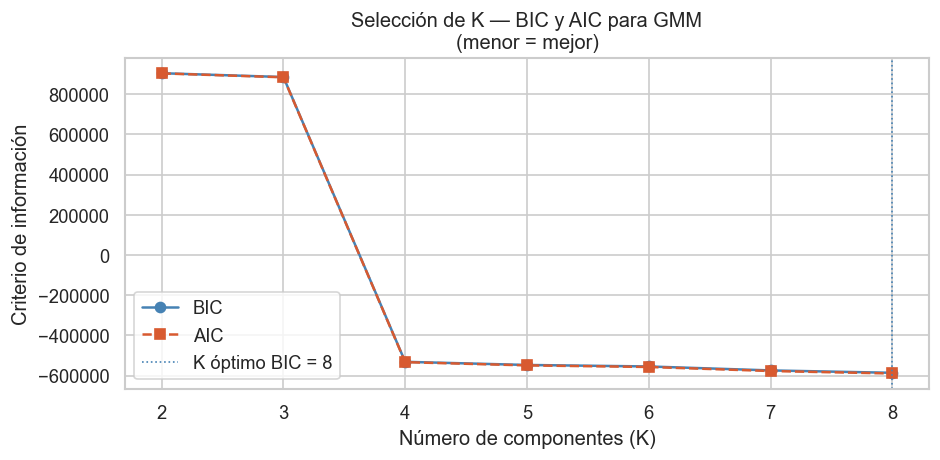

K óptimo según BIC: 8


In [26]:
K_range_gmm = range(2, 9)
bic_scores  = []
aic_scores  = []

for k in K_range_gmm:
    gmm = GaussianMixture(n_components=k, covariance_type='full',
                          random_state=42, max_iter=200)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_range_gmm, bic_scores, 'o-', label='BIC', color='steelblue')
ax.plot(K_range_gmm, aic_scores, 's--', label='AIC', color='#D85A30')
ax.axvline(np.argmin(bic_scores) + 2, color='steelblue', lw=1, linestyle=':',
           label=f'K óptimo BIC = {np.argmin(bic_scores)+2}')
ax.set_xlabel('Número de componentes (K)')
ax.set_ylabel('Criterio de información')
ax.set_title('Selección de K — BIC y AIC para GMM\n(menor = mejor)')
ax.legend(); ax.set_xticks(list(K_range_gmm))
plt.tight_layout()
plt.show()

K_GMM = int(np.argmin(bic_scores)) + 2
print(f'K óptimo según BIC: {K_GMM}')

In [27]:
# ── Ajuste final GMM ──────────────────────────────────────────────────────
gmm_final = GaussianMixture(n_components=K_GMM, covariance_type='full',
                             random_state=42, max_iter=300)
gmm_final.fit(X_scaled)

df_work['cluster_gmm']      = gmm_final.predict(X_scaled)
probs                        = gmm_final.predict_proba(X_scaled)
df_work['gmm_max_prob']     = probs.max(axis=1)

print(f'Log-verosimilitud del modelo: {gmm_final.score(X_scaled) * len(X_scaled):,.0f}')
print(f'\nPeso (pi) de cada componente:')
for i, w in enumerate(gmm_final.weights_):
    print(f'  Componente {i}: {w:.4f} ({w*100:.1f}%)')

print(f'\nMedia de probabilidad máxima de asignación: {df_work["gmm_max_prob"].mean():.3f}')
print('(cercano a 1.0 = asignaciones muy seguras; cercano a 1/K = mucha incertidumbre)')

Log-verosimilitud del modelo: 294,919

Peso (pi) de cada componente:
  Componente 0: 0.2833 (28.3%)
  Componente 1: 0.2163 (21.6%)
  Componente 2: 0.0285 (2.8%)
  Componente 3: 0.0683 (6.8%)
  Componente 4: 0.0015 (0.1%)
  Componente 5: 0.1597 (16.0%)
  Componente 6: 0.0733 (7.3%)
  Componente 7: 0.1692 (16.9%)

Media de probabilidad máxima de asignación: 0.916
(cercano a 1.0 = asignaciones muy seguras; cercano a 1/K = mucha incertidumbre)


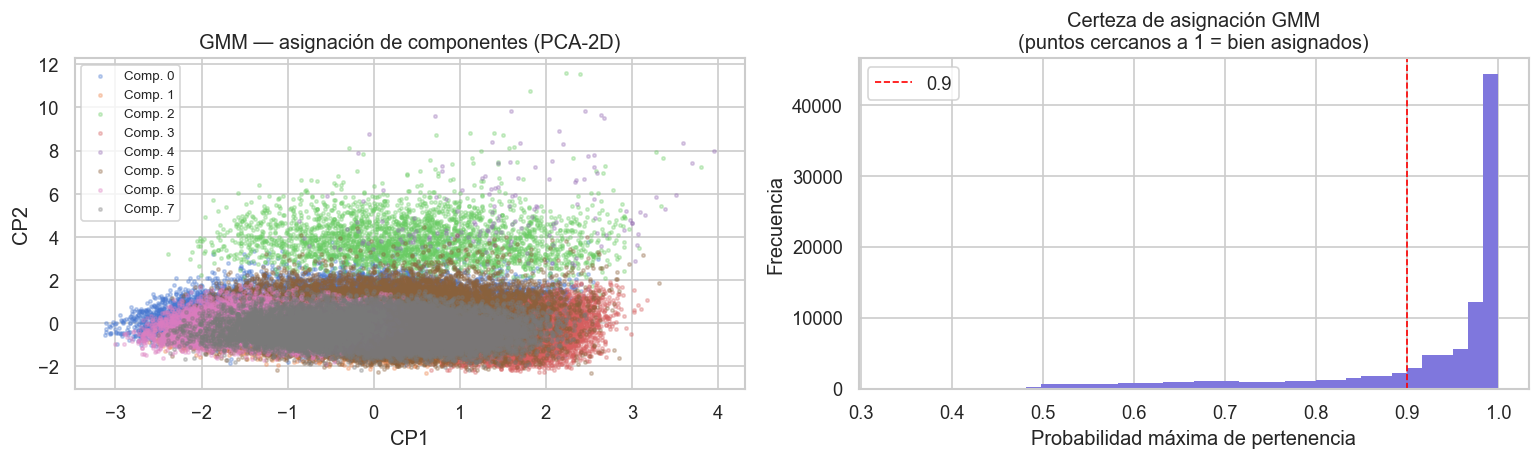

In [28]:
# ── Distribución de probabilidades de membresía ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# scatter en PCA-2D coloreado por cluster GMM
for k in range(K_GMM):
    mask = df_work['cluster_gmm'] == k
    axes[0].scatter(X_pca2_km[mask.values, 0], X_pca2_km[mask.values, 1],
                    s=4, alpha=0.3, label=f'Comp. {k}', rasterized=True)
axes[0].set_xlabel('CP1'); axes[0].set_ylabel('CP2')
axes[0].set_title('GMM — asignación de componentes (PCA-2D)')
axes[0].legend(fontsize=8)

# histograma de certeza de asignación
axes[1].hist(df_work['gmm_max_prob'], bins=40, color='#7F77DD', edgecolor='none')
axes[1].axvline(0.9, color='red', lw=1, linestyle='--', label='0.9')
axes[1].set_xlabel('Probabilidad máxima de pertenencia')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Certeza de asignación GMM\n(puntos cercanos a 1 = bien asignados)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Spectral Clustering

### ¿Qué hace?
Spectral Clustering construye un grafo de similitud entre puntos,
calcula los eigenvectores del Laplaciano de ese grafo, y aplica K-Means
en ese espacio de eigenvectores. Puede encontrar clusters de formas arbitrarias
que K-Means no detecta.

### Cuándo es mejor que K-Means
- Clusters no convexos (anillos, medias lunas, espirales).
- Datos con estructura de manifold no lineal.

### Limitación
Costo computacional O(n³) — **necesita muestra más pequeña** que los otros métodos.

Silhouette Spectral Clustering (n=5000, K=4): 0.1352


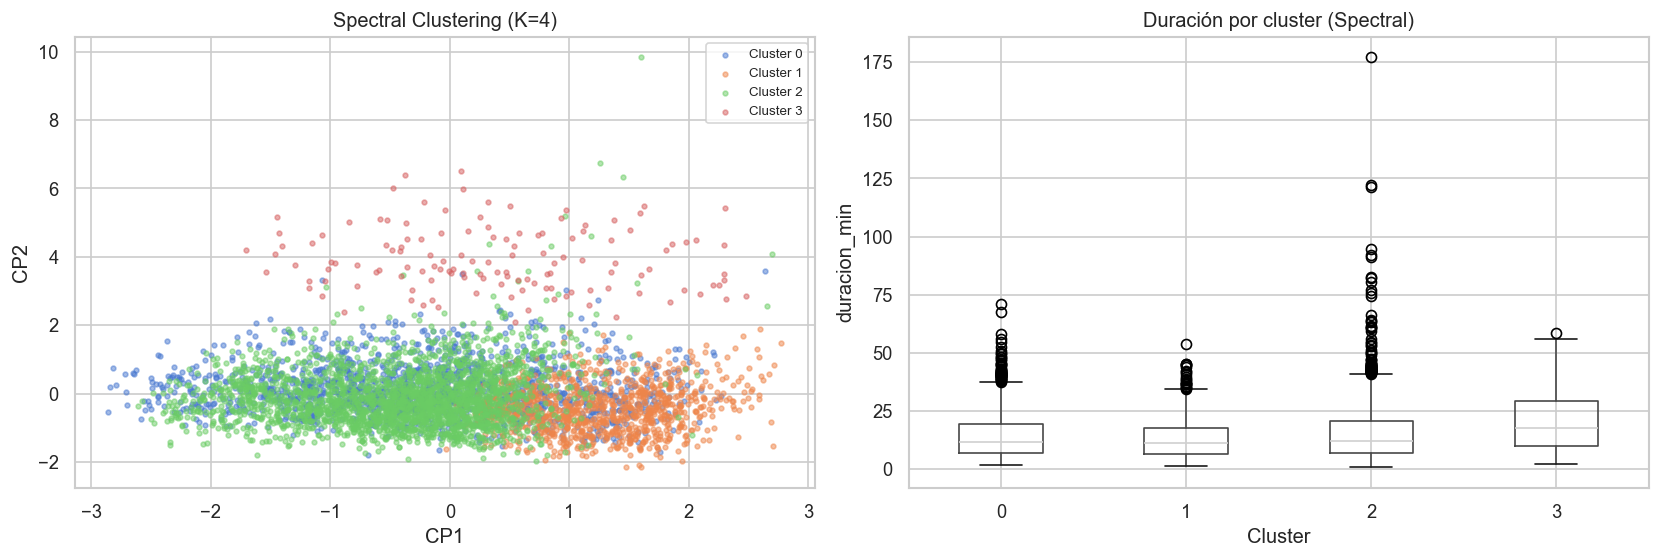


Nota: Spectral Clustering no produce centroides, por lo que la
interpretación se basa en la distribución de las variables originales
dentro de cada cluster, no en un punto representativo central.



In [29]:
# Spectral es costoso: reducimos a 5 000 puntos
N_SPEC   = 5000
idx_spec = np.random.choice(len(X_scaled), N_SPEC, replace=False)
X_spec   = X_scaled[idx_spec]

spec = SpectralClustering(n_clusters=K_OPTIMO, affinity='nearest_neighbors',
                        n_neighbors=15, random_state=42, n_jobs=-1)
labels_spec = spec.fit_predict(X_spec)

sil_spec = silhouette_score(X_spec, labels_spec)
print(f'Silhouette Spectral Clustering (n={N_SPEC}, K={K_OPTIMO}): {sil_spec:.4f}')

# ── Visualización ─────────────────────────────────────────────────────────
X_pca2_spec = pca2.transform(X_spec)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k in range(K_OPTIMO):
    mask = labels_spec == k
    axes[0].scatter(X_pca2_spec[mask, 0], X_pca2_spec[mask, 1],
                    s=8, alpha=0.5, label=f'Cluster {k}')
axes[0].set_title(f'Spectral Clustering (K={K_OPTIMO})')
axes[0].set_xlabel('CP1'); axes[0].set_ylabel('CP2')
axes[0].legend(fontsize=8)

# distribución de duración por cluster spectral
df_spec = df_work.iloc[idx_spec].copy()
df_spec['cluster_spectral'] = labels_spec
df_spec.boxplot(column='duracion_min', by='cluster_spectral', ax=axes[1])
axes[1].set_title('Duración por cluster (Spectral)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('duracion_min')
plt.suptitle('')
plt.tight_layout()
plt.show()

print("""
Nota: Spectral Clustering no produce centroides, por lo que la
interpretación se basa en la distribución de las variables originales
dentro de cada cluster, no en un punto representativo central.
""")

## 10. KNN — K-Nearest Neighbors (clasificación de género)

### Tarea
Predecir el género del usuario (M/F) a partir de las características del viaje.
Es una tarea de **clasificación binaria**.

### ¿Cómo funciona KNN?
Para clasificar un punto nuevo, busca los K vecinos más cercanos en el espacio de features
y asigna la clase mayoritaria entre ellos. Es un método **no paramétrico**: no aprende
una función explícita, sólo memoriza los datos de entrenamiento.

### Elección de K
- K pequeño (1-3): muy sensible a ruido (overfitting).
- K grande: suaviza las fronteras pero puede perder detalle (underfitting).
- Elegimos K con validación cruzada.

In [30]:
# ── Preparar X e y ────────────────────────────────────────────────────────
FEATURES_KNN = ['duracion_min','Edad_Usuario','hora_retiro','mes','es_circular']

df_knn = df_work[FEATURES_KNN + ['genero_M']].dropna()
X_knn  = scaler.fit_transform(df_knn[FEATURES_KNN])
y_knn  = df_knn['genero_M'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y_knn, test_size=0.25, random_state=42, stratify=y_knn)

print(f'Train: {X_train.shape[0]:,}  Test: {X_test.shape[0]:,}')
print(f'Proporción M en train: {y_train.mean():.3f}  |  en test: {y_test.mean():.3f}')

Train: 75,000  Test: 25,000
Proporción M en train: 0.708  |  en test: 0.708


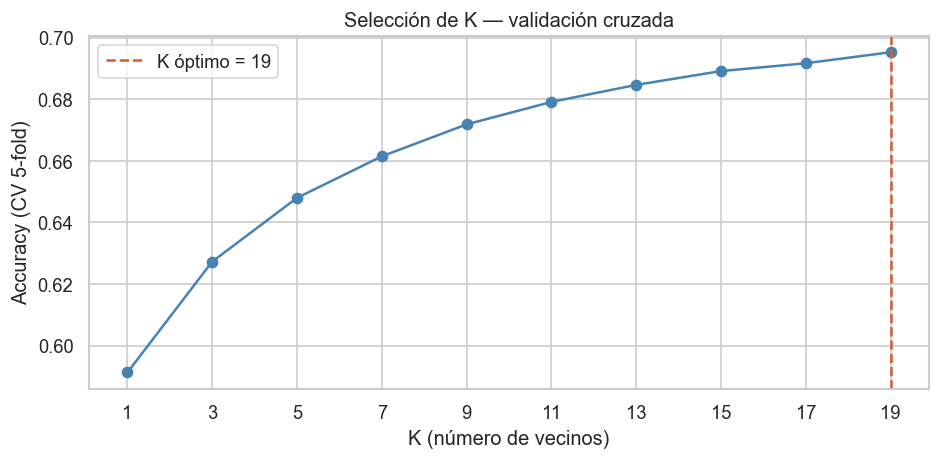

K óptimo: 19  |  Accuracy CV: 0.6953


In [31]:
# ── Selección de K óptimo por validación cruzada ─────────────────────────
K_vals = list(range(1, 21, 2))
cv_scores = []

for k in K_vals:
    knn_cv = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_vals, cv_scores, 'o-', color='steelblue')
best_k = K_vals[np.argmax(cv_scores)]
ax.axvline(best_k, color='#D85A30', lw=1.5, linestyle='--', label=f'K óptimo = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Selección de K — validación cruzada')
ax.legend(); ax.set_xticks(K_vals)
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}  |  Accuracy CV: {max(cv_scores):.4f}')

=== Reporte de clasificación ===
              precision    recall  f1-score   support

           F       0.35      0.05      0.08      7295
           M       0.71      0.96      0.82     17705

    accuracy                           0.70     25000
   macro avg       0.53      0.51      0.45     25000
weighted avg       0.61      0.70      0.60     25000



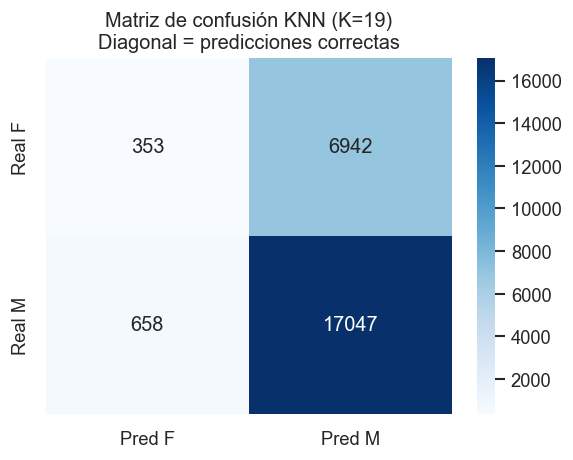


Interpretación de métricas:
  - Precision: de los que predije como M, ¿qué fracción realmente es M?
  - Recall:    de todos los M reales, ¿qué fracción encontré?
  - F1:        media armónica de precision y recall.
  - Si el accuracy es cercano al porcentaje de la clase mayoritaria,
    el modelo podría estar simplemente prediciendo siempre esa clase.



In [32]:
# ── Evaluación en test ────────────────────────────────────────────────────
knn_final = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train, y_train)
y_pred_knn = knn_final.predict(X_test)

print('=== Reporte de clasificación ===')
print(classification_report(y_test, y_pred_knn, target_names=['F','M']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred F','Pred M'], yticklabels=['Real F','Real M'])
ax.set_title(f'Matriz de confusión KNN (K={best_k})\n'
             'Diagonal = predicciones correctas')
plt.tight_layout()
plt.show()

print("""
Interpretación de métricas:
  - Precision: de los que predije como M, ¿qué fracción realmente es M?
  - Recall:    de todos los M reales, ¿qué fracción encontré?
  - F1:        media armónica de precision y recall.
  - Si el accuracy es cercano al porcentaje de la clase mayoritaria,
    el modelo podría estar simplemente prediciendo siempre esa clase.
""")

## 11. Regresión — predicción de duración del viaje

### Tarea
Predecir `duracion_min` a partir de las características del viaje.
Es una tarea de **regresión** (variable continua).

### Modelos comparados
| Modelo | Penalización | Shrinkage | Feature selection |
|---|---|---|---|
| OLS (Lineal) | Ninguna | No | No |
| Ridge | L2 (norma cuadrática) | Sí | No (coefs pequeños) |
| Lasso | L1 (norma absoluta) | Sí | Sí (algunos coefs = 0) |
| ElasticNet | L1 + L2 | Sí | Sí |

### Métricas de evaluación
- **R²**: fracción de varianza explicada. 1 = perfecto, 0 = sin poder predictivo.
- **RMSE**: error cuadrático medio. En las mismas unidades que y (minutos).
- **MAE**: error absoluto medio. Más robusto a outliers.

In [33]:
FEATURES_REG = ['Edad_Usuario','hora_retiro','mes','genero_M','es_circular', 'lat_retiro', 'lon_retiro']
df_reg = df_work[FEATURES_REG + ['duracion_min']].dropna()

X_reg = scaler.fit_transform(df_reg[FEATURES_REG])
y_reg = df_reg['duracion_min'].values

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)
print(f'Train: {X_tr.shape[0]:,}  Test: {X_te.shape[0]:,}')

Train: 75,000  Test: 25,000


In [34]:
# ── Ajuste y evaluación de los 4 modelos ─────────────────────────────────
modelos = {
    'OLS (Lineal)': LinearRegression(),
    'Ridge (L2)':   Ridge(alpha=1.0),
    'Lasso (L1)':   Lasso(alpha=0.01, max_iter=5000),
    'ElasticNet':   ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_tr, y_tr)
    y_hat = modelo.predict(X_te)
    resultados[nombre] = {
        'R²':  r2_score(y_te, y_hat),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_hat)),
        'MAE':  np.mean(np.abs(y_te - y_hat)),
        'coefs': getattr(modelo, 'coef_', None)
    }

df_resultados = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'coefs'}
                               for k, v in resultados.items()}).T.round(4)
print('=== Comparación de modelos de regresión ===')
print(df_resultados.to_string())

=== Comparación de modelos de regresión ===
                  R²     RMSE     MAE
OLS (Lineal)  0.0139  10.9452  8.0809
Ridge (L2)    0.0139  10.9452  8.0809
Lasso (L1)    0.0138  10.9457  8.0815
ElasticNet    0.0138  10.9456  8.0814


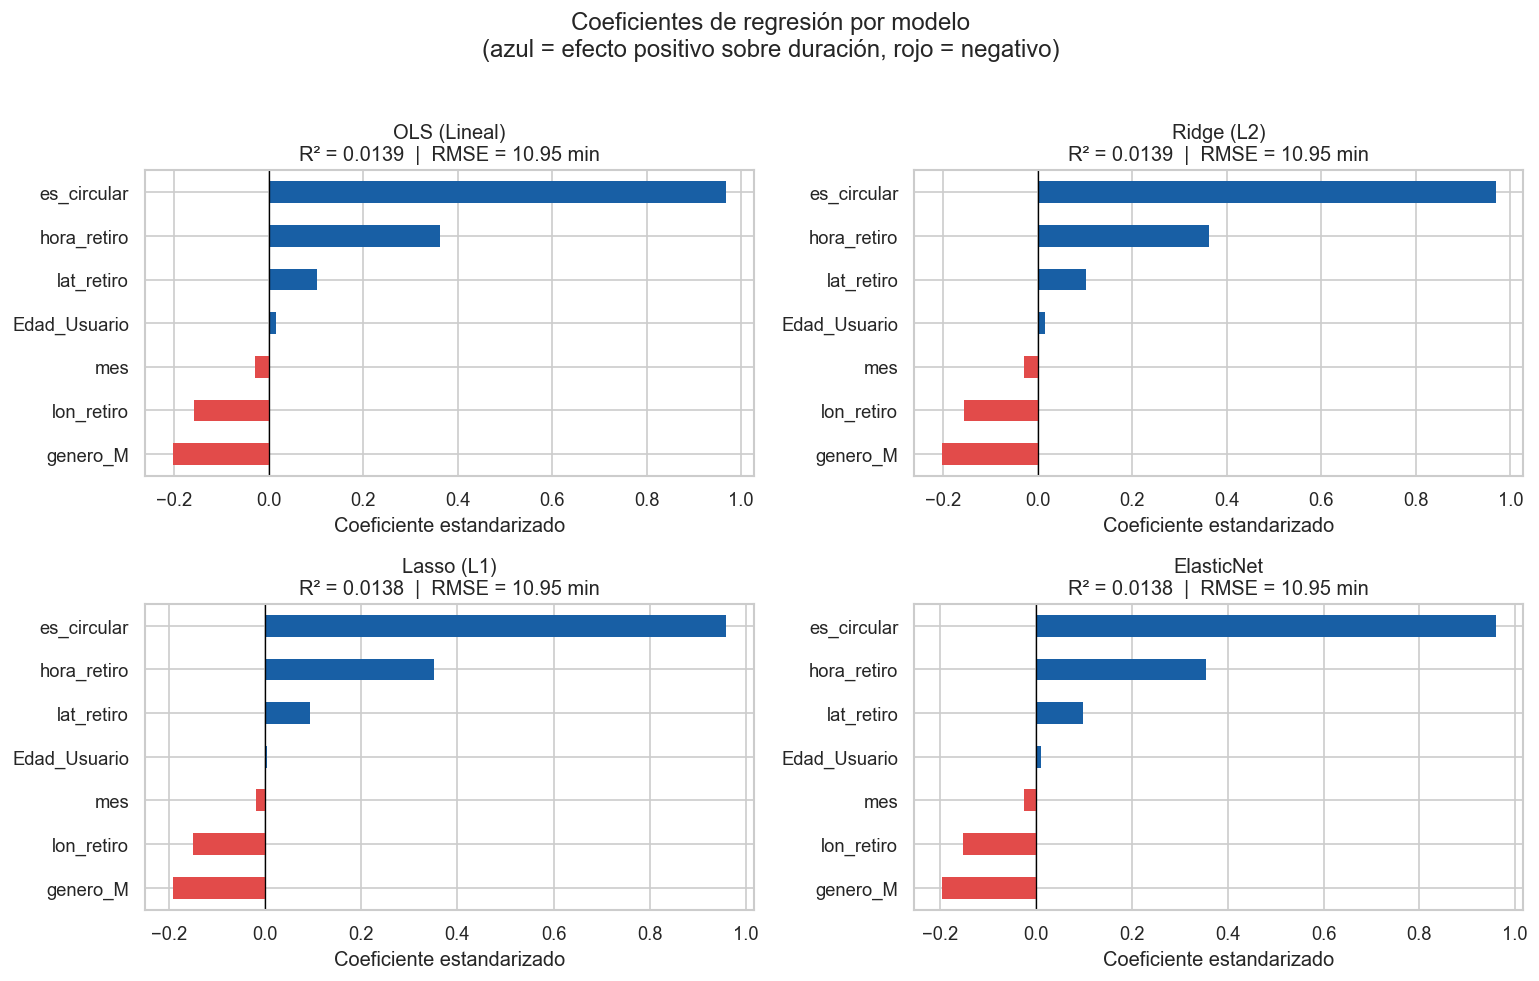


Interpretación de coeficientes estandarizados:
  - El coeficiente de cada variable representa el cambio en duracion_min
    por cada desviación estándar de aumento en esa variable, manteniendo
    las demás constantes.
  - Variables con coeficiente cercano a 0 tienen poco poder predictivo.
  - LASSO pone exactamente a 0 las variables que no aportan.



In [35]:
# ── Coeficientes estandarizados ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, (nombre, res) in zip(axes.flatten(), resultados.items()):
    coefs = pd.Series(res['coefs'], index=FEATURES_REG).sort_values()
    colors_bar = ['#E24B4A' if v < 0 else '#185FA5' for v in coefs]
    coefs.plot.barh(ax=ax, color=colors_bar, edgecolor='none')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{nombre}\nR² = {res["R²"]:.4f}  |  RMSE = {res["RMSE"]:.2f} min')
    ax.set_xlabel('Coeficiente estandarizado')

plt.suptitle('Coeficientes de regresión por modelo\n'
             '(azul = efecto positivo sobre duración, rojo = negativo)', y=1.02)
plt.tight_layout()
plt.show()

print("""
Interpretación de coeficientes estandarizados:
  - El coeficiente de cada variable representa el cambio en duracion_min
    por cada desviación estándar de aumento en esa variable, manteniendo
    las demás constantes.
  - Variables con coeficiente cercano a 0 tienen poco poder predictivo.
  - LASSO pone exactamente a 0 las variables que no aportan.
""")

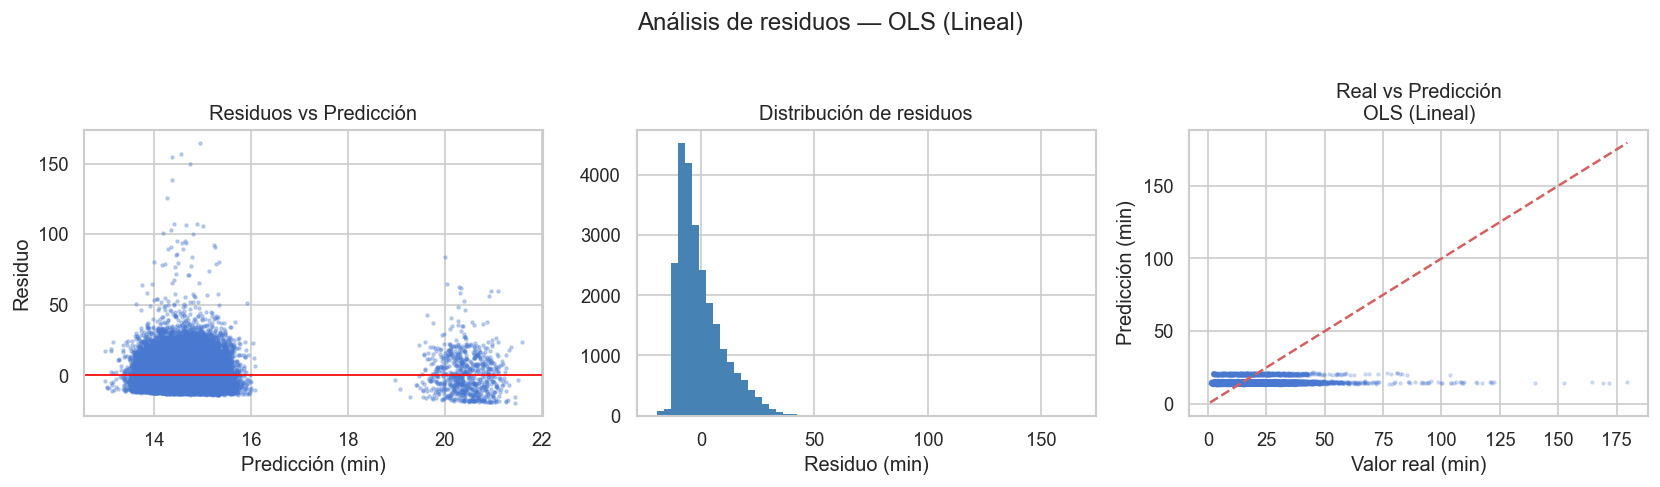

In [36]:
# ── Residuos del mejor modelo ─────────────────────────────────────────────
mejor_modelo_nombre = df_resultados['R²'].idxmax()
mejor_modelo = modelos[mejor_modelo_nombre]
y_hat_best = mejor_modelo.predict(X_te)
residuos = y_te - y_hat_best

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_hat_best, residuos, s=3, alpha=0.3, rasterized=True)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicción (min)'); axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs Predicción')

axes[1].hist(residuos, bins=60, color='steelblue', edgecolor='none')
axes[1].set_xlabel('Residuo (min)'); axes[1].set_title('Distribución de residuos')

axes[2].scatter(y_te, y_hat_best, s=3, alpha=0.2, rasterized=True)
axes[2].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=1.5)
axes[2].set_xlabel('Valor real (min)'); axes[2].set_ylabel('Predicción (min)')
axes[2].set_title(f'Real vs Predicción\n{mejor_modelo_nombre}')

plt.suptitle(f'Análisis de residuos — {mejor_modelo_nombre}', y=1.01)
plt.tight_layout()
plt.show()

## 12. KDE — Kernel Density Estimation

### ¿Qué hace?
KDE estima la función de densidad de probabilidad de los datos de forma no paramétrica.
Para cada punto se coloca un "kernel" (función suavizante) y se suman para obtener
la densidad total. El parámetro `bandwidth` controla el suavizado.

### Usos en este análisis
- Estimar la densidad de duración del viaje.
- Comparar las distribuciones de hombres vs mujeres.
- Detectar modas y colas de la distribución.

In [37]:
# ── Selección de bandwidth por validación cruzada ─────────────────────────
from sklearn.model_selection import GridSearchCV

X_kde_dur = df_work['duracion_min'].values.reshape(-1, 1)

params = {'bandwidth': np.logspace(-1, 1, 20)}
grid_kde = GridSearchCV(KernelDensity(kernel='gaussian'), params, cv=5)
grid_kde.fit(X_kde_dur[:10000])   # muestra para cv rápido

bw_optimo = grid_kde.best_params_['bandwidth']
print(f'Bandwidth óptimo (CV): {bw_optimo:.4f}')

Bandwidth óptimo (CV): 1.4384


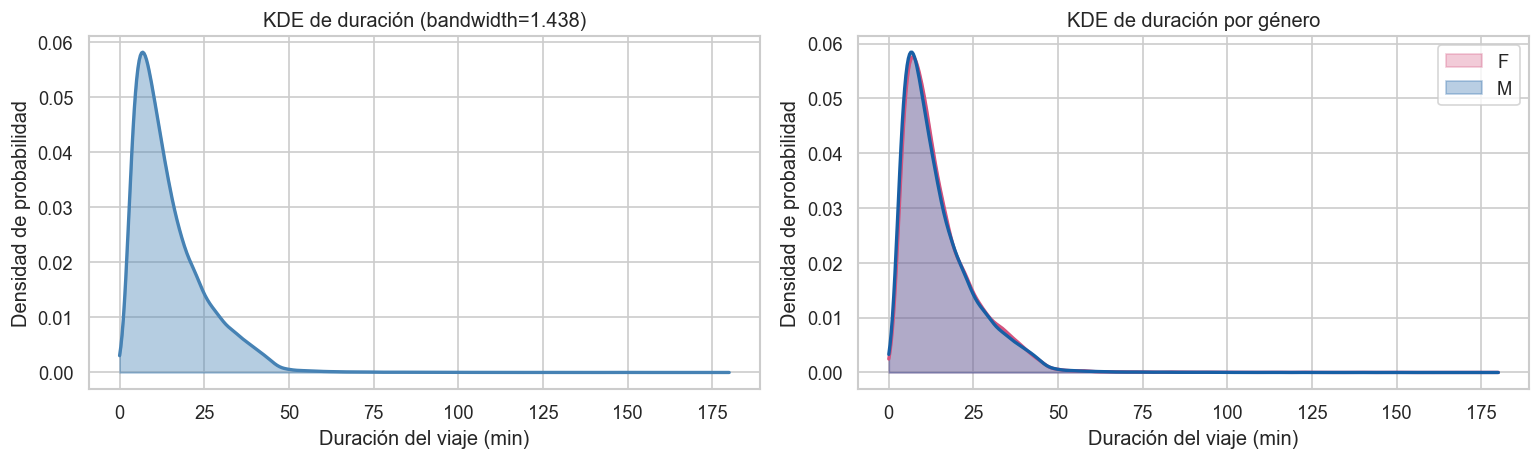


Interpretación:
  - La moda de la distribución indica la duración más frecuente.
  - Distribuciones con cola derecha larga sugieren presencia de viajes atípicamente largos.
  - Diferencias en las curvas por género sugieren patrones de uso distintos.



In [38]:
# ── KDE de duración ───────────────────────────────────────────────────────
x_range = np.linspace(0, 180, 500).reshape(-1, 1)

kde_dur = KernelDensity(kernel='gaussian', bandwidth=bw_optimo)
kde_dur.fit(X_kde_dur)
log_dens = kde_dur.score_samples(x_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# densidad total
axes[0].fill_between(x_range.ravel(), np.exp(log_dens), alpha=0.4, color='steelblue')
axes[0].plot(x_range, np.exp(log_dens), color='steelblue', lw=2)
axes[0].set_xlabel('Duración del viaje (min)')
axes[0].set_ylabel('Densidad de probabilidad')
axes[0].set_title(f'KDE de duración (bandwidth={bw_optimo:.3f})')

# KDE por género
for genero, color, label in [(0, '#D4537E', 'F'), (1, '#185FA5', 'M')]:
    datos_g = df_work[df_work['genero_M'] == genero]['duracion_min'].values.reshape(-1,1)
    kde_g = KernelDensity(kernel='gaussian', bandwidth=bw_optimo)
    kde_g.fit(datos_g)
    log_d = kde_g.score_samples(x_range)
    axes[1].fill_between(x_range.ravel(), np.exp(log_d), alpha=0.3, color=color, label=label)
    axes[1].plot(x_range, np.exp(log_d), color=color, lw=2)

axes[1].set_xlabel('Duración del viaje (min)')
axes[1].set_ylabel('Densidad de probabilidad')
axes[1].set_title('KDE de duración por género')
axes[1].legend()

plt.tight_layout()
plt.show()

print("""
Interpretación:
  - La moda de la distribución indica la duración más frecuente.
  - Distribuciones con cola derecha larga sugieren presencia de viajes atípicamente largos.
  - Diferencias en las curvas por género sugieren patrones de uso distintos.
""")

## 13. Manifold Learning — t-SNE y LLE

### ¿Qué hace?
El Manifold Learning asume que los datos de alta dimensión viven en una variedad
(manifold) de dimensión más baja. t-SNE y LLE encuentran esa representación de baja
dimensión preservando las relaciones de vecindad local.

### t-SNE (t-distributed Stochastic Neighbor Embedding)
- Muy bueno para **visualizar clusters** en 2D.
- Preserva distancias locales pero **no globales** (la distancia entre clusters en 2D
  no refleja la distancia real en el espacio original).
- `perplexity` controla cuántos vecinos se consideran (5–50 típicamente).

### LLE (Locally Linear Embedding)
- Reconstruye cada punto como combinación lineal de sus vecinos.
- Preserva mejor la estructura global que t-SNE.

> Nota: ambos son costosos — usamos muestra de 5 000.

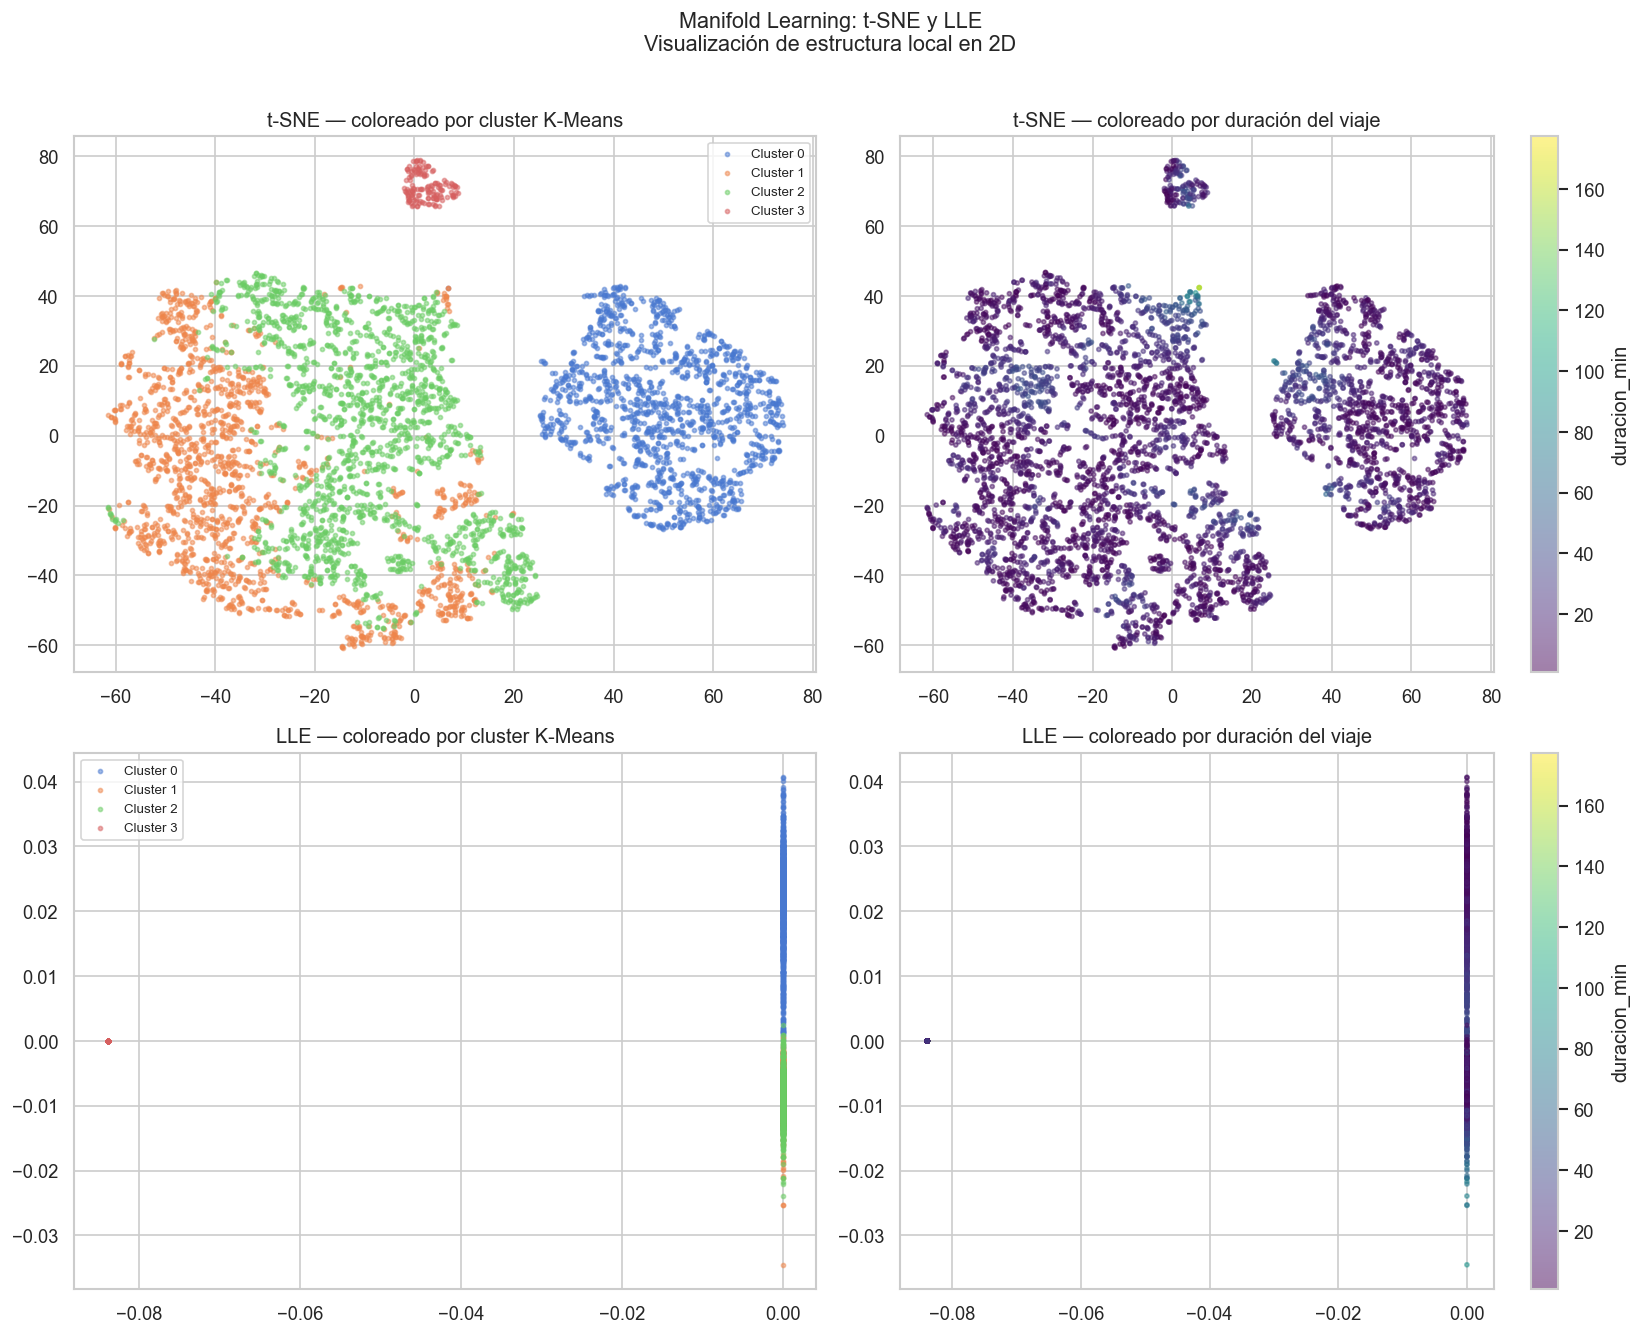


Interpretación:
  - Grupos bien separados en t-SNE confirman que los clusters tienen estructura real.
  - Gradientes de color suaves indican que la duración varía continuamente a través
    del espacio de features (sin saltos abruptos).
  - LLE puede revelar estructura que t-SNE distorsiona, o viceversa.



In [39]:
N_MAN   = 5000
idx_man = np.random.choice(len(X_scaled), N_MAN, replace=False)
X_man   = X_scaled[idx_man]
labels_man = df_work['cluster_kmeans'].values[idx_man]
dur_man    = df_work['duracion_min'].values[idx_man]

# ── t-SNE ─────────────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_man)

# ── LLE ───────────────────────────────────────────────────────────────────
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=15, random_state=42)
X_lle = lle.fit_transform(X_man)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

for row, (X_emb, titulo) in enumerate([(X_tsne, 't-SNE'), (X_lle, 'LLE')]):
    # coloreado por cluster
    for k in range(K_OPTIMO):
        mask = labels_man == k
        axes[row, 0].scatter(X_emb[mask, 0], X_emb[mask, 1], s=6, alpha=0.5, label=f'Cluster {k}')
    axes[row, 0].set_title(f'{titulo} — coloreado por cluster K-Means')
    axes[row, 0].legend(fontsize=8)

    # coloreado por duración
    sc = axes[row, 1].scatter(X_emb[:, 0], X_emb[:, 1], c=dur_man,
                              cmap='viridis', s=6, alpha=0.5, rasterized=True)
    plt.colorbar(sc, ax=axes[row, 1], label='duracion_min')
    axes[row, 1].set_title(f'{titulo} — coloreado por duración del viaje')

plt.suptitle('Manifold Learning: t-SNE y LLE\n'
             'Visualización de estructura local en 2D', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print("""
Interpretación:
  - Grupos bien separados en t-SNE confirman que los clusters tienen estructura real.
  - Gradientes de color suaves indican que la duración varía continuamente a través
    del espacio de features (sin saltos abruptos).
  - LLE puede revelar estructura que t-SNE distorsiona, o viceversa.
""")

## 14. NMF — Non-negative Matrix Factorization

### ¿Qué hace?
NMF descompone la matriz X ≈ W·H donde W y H tienen entradas **no negativas**.
Esto produce una factorización **aditiva** e interpretable: cada observación
es una combinación positiva de K "patrones base".

### Requisitos
- Las features deben ser **no negativas**. Usamos `MinMaxScaler` en lugar de `StandardScaler`.

### Diferencia con PCA
- PCA permite coeficientes negativos y positivos (difícil de interpretar).
- NMF sólo permite combinaciones aditivas → componentes más interpretables.

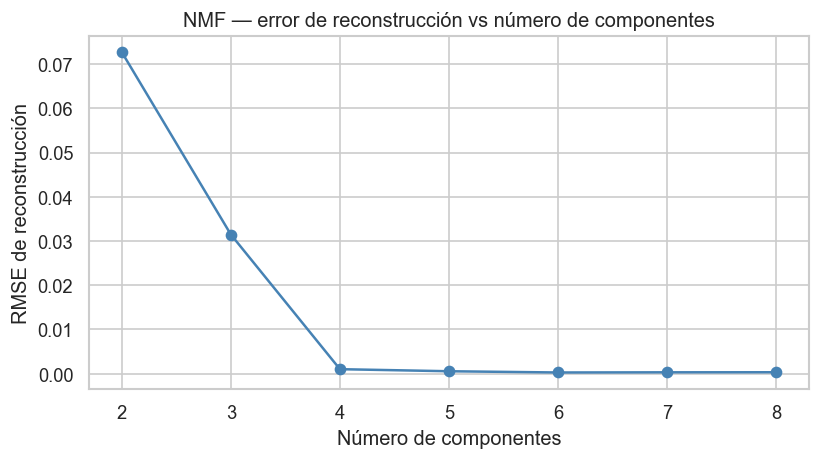

K sugerido (codo del error): 2


In [40]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import NMF

VARS_NMF = ['duracion_min','Edad_Usuario','hora_retiro','mes']

df_nmf_data = df_work[VARS_NMF].dropna()
mms = MinMaxScaler()
X_nmf = mms.fit_transform(df_nmf_data)

# ── Elegir K con el error de reconstrucción ───────────────────────────────
K_nmf_range = range(2, 9)
errores_nmf = []

for k in K_nmf_range:
    nmf_tmp = NMF(n_components=k, random_state=42, max_iter=500)
    W = nmf_tmp.fit_transform(X_nmf)
    X_rec = W @ nmf_tmp.components_
    errores_nmf.append(np.sqrt(mean_squared_error(X_nmf, X_rec)))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_nmf_range, errores_nmf, 'o-', color='steelblue')
ax.set_xlabel('Número de componentes'); ax.set_ylabel('RMSE de reconstrucción')
ax.set_title('NMF — error de reconstrucción vs número de componentes')
ax.set_xticks(list(K_nmf_range))
plt.tight_layout()
plt.show()

K_NMF = int(np.argmin(np.gradient(errores_nmf)) + 2)
print(f'K sugerido (codo del error): {K_NMF}')

Matriz H (componentes — qué combinación de variables forma cada patrón):
          duracion_min  Edad_Usuario  hora_retiro     mes
Patrón 1        1.6880        4.5858      16.3013  0.0000
Patrón 2        0.3117        0.9017       0.9063  9.1963


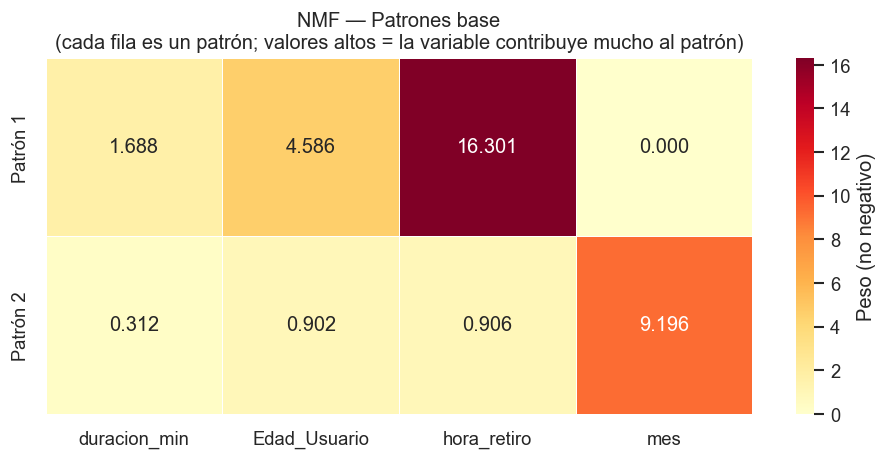


Distribución de patrones:
patrón_nmf
0    40586
1    59414
Name: count, dtype: int64


In [41]:
# ── Ajuste final NMF ──────────────────────────────────────────────────────
nmf_final = NMF(n_components=K_NMF, random_state=42, max_iter=500)
W_final = nmf_final.fit_transform(X_nmf)
H_final = nmf_final.components_

print('Matriz H (componentes — qué combinación de variables forma cada patrón):')
df_H = pd.DataFrame(H_final, columns=VARS_NMF,
                    index=[f'Patrón {i+1}' for i in range(K_NMF)])
print(df_H.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_H, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Peso (no negativo)'})
ax.set_title('NMF — Patrones base\n'
             '(cada fila es un patrón; valores altos = la variable contribuye mucho al patrón)')
plt.tight_layout()
plt.show()

# asignar patrón dominante a cada viaje
df_work['patrón_nmf'] = W_final.argmax(axis=1)
print('\nDistribución de patrones:')
print(df_work['patrón_nmf'].value_counts().sort_index())

## 15. Resumen comparativo de métodos

Esta celda consolida los resultados principales de todos los métodos para facilitar
la redacción del informe.

In [43]:
print('='*70)
print('RESUMEN DE RESULTADOS')
print('='*70)

# ── métricas seguras ─────────────────────────────────────────────────────
sil_km = silhouette_score(X_scaled, df_work['cluster_kmeans'], sample_size=10000, random_state=42)
db_km  = davies_bouldin_score(X_scaled, df_work['cluster_kmeans'])

# jerárquico SOLO en subset
sil_hier = silhouette_score(X_small, df_small['cluster_hier'], sample_size=5000, random_state=42)

# GMM
gmm_prob_mean = df_work['gmm_max_prob'].mean() if 'gmm_max_prob' in df_work.columns else float('nan')

# ── impresión ────────────────────────────────────────────────────────────
print(f"""
SELECCIÓN DE VARIABLES
  - Variables con mayor información mutua respecto a duracion_min: ver gráfica sección 3.2
  - LASSO (alpha=0.01) seleccionó: {vars_seleccionadas if 'vars_seleccionadas' in globals() else 'N/A'}

PCA
  - CPs necesarios para explicar 80% de varianza: {n_80}
  - CPs necesarios para explicar 95% de varianza: {n_95}
  - Variable con mayor loading en CP1: {loadings['CP1'].abs().idxmax() if 'loadings' in globals() else 'N/A'}

K-MEANS (K={K_OPTIMO})
  - Silhouette: {sil_km:.4f}
  - Davies-Bouldin: {db_km:.4f}

JERÁRQUICO (K={K_HIER}, Ward)
  - Silhouette (subset): {sil_hier:.4f}
  - ARI vs K-Means: ver sección de comparación

GMM (K={K_GMM})
  - BIC mínimo en K={K_GMM}
  - Certeza media de asignación: {gmm_prob_mean:.3f}

KNN (K={best_k}) — clasificación de género
  - Accuracy test: ver classification_report sección 10

REGRESIÓN (mejor modelo: {mejor_modelo_nombre})
  - R²: {df_resultados.loc[mejor_modelo_nombre, 'R²']:.4f}
  - RMSE: {df_resultados.loc[mejor_modelo_nombre, 'RMSE']:.2f} min

""")

RESUMEN DE RESULTADOS

SELECCIÓN DE VARIABLES
  - Variables con mayor información mutua respecto a duracion_min: ver gráfica sección 3.2
  - LASSO (alpha=0.01) seleccionó: ['Edad_Usuario', 'hora_retiro', 'mes', 'genero_M', 'es_circular', 'weekend', 'lat_retiro', 'lon_retiro']

PCA
  - CPs necesarios para explicar 80% de varianza: 7
  - CPs necesarios para explicar 95% de varianza: 8
  - Variable con mayor loading en CP1: lat_retiro

K-MEANS (K=4)
  - Silhouette: 0.1510
  - Davies-Bouldin: 1.8995

JERÁRQUICO (K=4, Ward)
  - Silhouette (subset): 0.1342
  - ARI vs K-Means: ver sección de comparación

GMM (K=8)
  - BIC mínimo en K=8
  - Certeza media de asignación: 0.916

KNN (K=19) — clasificación de género
  - Accuracy test: ver classification_report sección 10

REGRESIÓN (mejor modelo: OLS (Lineal))
  - R²: 0.0139
  - RMSE: 10.95 min


